# Notebook 07: Paper Results: Chapter 4 (Results and Discussion)

Three-pillar evaluation framework for hybrid bias correction of satellite precipitation:

1. **Adjusting Values** (mean & magnitude): Relative Bias, Std. Dev. Ratio
2. **Aligning Distributions** (statistical shape): KS p-value, Wet-Day Freq. Ratio, Mean Wet-Day Precip Ratio
3. **Preserving Extremes** (tail accuracy): Q95 Ratio, Q99 Ratio

Plus **Event Detection** (POD, CSI, FAR) and **Temporal Skill** (Pearson Corr, RMSE, NSE).

All tables and figures for the paper are generated here.

In [19]:
from google.colab import drive
import os

# Check if the drive is mounted
if os.path.exists("/content/drive"):
    # Try to unmount
    try:
        drive.flush_and_unmount()
        print("Successfully unmounted")
    except:
        print("Unmount failed, the drive might not be mounted or busy")

# Mount the drive
drive.mount("/content/drive")

Successfully unmounted
Mounted at /content/drive


In [20]:
# In Google Colab, almost all packages already available, except netCDF4
!pip install netCDF4 cartopy

In [21]:
# -- Setup --------------------------------------------------------------------
import os
import sys
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.dpi': 300,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
})

# -- Project root & config ---------------------------------------------------
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = '/content/drive/MyDrive/hybrid-bias-correction'
# project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.config import initialize_config
initialize_config(os.path.join(project_root, 'config.yml'))
from src import config

# -- Constants ----------------------------------------------------------------
METHODS = ['ls', 'lseqm', 'lseqmdl']
METHOD_LABELS = ['LS', 'LSEQM', 'LSEQM+DL']
DEKAD_MAP = {1: '01', 2: '11', 3: '21'}
ALL_PERIODS = [(m, d) for m in range(1, 13) for d in [1, 2, 3]]
WET_MONTHS = [10, 11, 12, 1, 2, 3]
DRY_MONTHS = [4, 5, 6, 7, 8, 9]

# -- Three-pillar metrics -----------------------------------------------------
PILLAR_METRICS = {
    'Value Adjustment': {
        'relative_bias': ('Relative Bias', 0),
        'stdev_ratio': ('Std. Dev. Ratio', 1.0),
    },
    'Distribution Alignment': {
        'ks_pvalue': ('KS p-value (%)', 100),
        'fpd_ratio': ('Wet-Day Freq. Ratio', 1.0),
        'mdwp_ratio': ('Mean Wet-Day Precip Ratio', 1.0),
    },
    'Extreme Preservation': {
        'p95_ratio': ('Q95 Ratio', 1.0),
        'p99_ratio': ('Q99 Ratio', 1.0),
    },
    'Event Detection': {
        'pod': ('POD', 1.0),
        'csi': ('CSI', 1.0),
        'far': ('FAR', 0),
    },
}

TEMPORAL_METRICS = {
    'pearson_correlation': ('Pearson Corr', 1.0),
    'rmse': ('RMSE (mm/day)', 0),
    'nse': ('NSE', 1.0),
}

# -- Path helpers -------------------------------------------------------------
OUTPUT_DIR = config.output_dir
FIG_DIR = os.path.join(OUTPUT_DIR, 'figures', 'paper')
os.makedirs(FIG_DIR, exist_ok=True)


def metrics_path(method, month, dekad):
    """Return path to metricssd NetCDF for given method/period."""
    dd = DEKAD_MAP[dekad]
    fname = f'{config.FILENAME_PREFIX}_metricssd_cpc_imergl_{method}_month{month:02d}_dekad{dd}.nc4'
    return os.path.join(OUTPUT_DIR, f'metrics_{method}', fname)


def quality_path(method, month, dekad):
    """Return path to qualitysd NetCDF for given method/period."""
    dd = DEKAD_MAP[dekad]
    fname = f'{config.FILENAME_PREFIX}_qualitysd_cpc_imergl_{method}_month{month:02d}_dekad{dd}.nc4'
    return os.path.join(OUTPUT_DIR, f'quality_{method}', fname)


def station_val_path(method, month, dekad):
    """Return path to station validation CSV."""
    dd = DEKAD_MAP[dekad]
    fname = f'station_validation_{method}_month{month:02d}_dekad{dd}.csv'
    return os.path.join(OUTPUT_DIR, 'station_validation', fname)


def multi_threshold_path(method, month, dekad):
    """Return path to multi-threshold summary CSV."""
    dd = DEKAD_MAP[dekad]
    fname = f'multi_threshold_summary_{method}_month{month:02d}_dekad{dd}.csv'
    return os.path.join(OUTPUT_DIR, 'station_validation', fname)


def save_fig(fig, name, dpi=200):
    """Save figure to paper figures directory."""
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'Saved: {path}')


def compute_spatial_medians(ds, var_names):
    """Compute spatial median (over lat/lon) for each variable."""
    result = {}
    for v in var_names:
        if v in ds.data_vars:
            vals = ds[v].values.ravel()
            vals = vals[np.isfinite(vals)]
            result[v] = np.median(vals) if len(vals) > 0 else np.nan
        else:
            result[v] = np.nan
    return result


def compute_ratio_medians(ds, pairs):
    """Compute spatial median of test/ref ratio for each pair.

    Parameters
    ----------
    ds : xarray.Dataset
    pairs : dict  {ratio_name: (test_var, ref_var)}

    Returns
    -------
    dict : {ratio_name: median_ratio}
    """
    result = {}
    for name, (test_var, ref_var) in pairs.items():
        if test_var in ds.data_vars and ref_var in ds.data_vars:
            test_vals = ds[test_var].values
            ref_vals = ds[ref_var].values
            mask = np.isfinite(test_vals) & np.isfinite(ref_vals) & (ref_vals > 0)
            if np.any(mask):
                ratio = test_vals[mask] / ref_vals[mask]
                result[name] = np.median(ratio)
            else:
                result[name] = np.nan
        else:
            result[name] = np.nan
    return result


print(f'Project root: {project_root}')
print(f'Output dir:   {OUTPUT_DIR}')
print(f'Figure dir:   {FIG_DIR}')
print(f'Periods:      {len(ALL_PERIODS)} dekads')
print('Setup complete.')


# -- Admin boundary overlay ---------------------------------------------------
import geopandas as gpd

def load_admin_boundaries():
    """Load ADM0 (regional countries) + ADM1 (Indonesia provinces)."""
    boundary_dir = os.path.join(project_root, 'data', 'downloads', 'boundary')

    # 1. ADM0 global (country outlines) clipped to study region
    adm0_path = os.path.join(boundary_dir,
                              'geoBoundariesCGAZ_ADM0',
                              'geoBoundariesCGAZ_ADM0.shp')
    adm0 = None
    if os.path.exists(adm0_path):
        adm0 = gpd.read_file(adm0_path, bbox=(90, -15, 145, 10))
        print(f'ADM0 loaded: {len(adm0)} countries in region')

    # 2. ADM1 Indonesia (provincial boundaries)
    adm1_path = os.path.join(boundary_dir,
                              'geoBoundaries-IDN-ADM1-all',
                              'geoBoundaries-IDN-ADM1_simplified.shp')
    adm1 = None
    if os.path.exists(adm1_path):
        adm1 = gpd.read_file(adm1_path)
        print(f'IDN ADM1 loaded: {len(adm1)} provinces')

    return adm0, adm1

def overlay_boundaries(ax, adm0, adm1,
                        adm0_color='#999999', adm0_lw=0.3,
                        adm1_color='#333333', adm1_lw=0.4):
    """Plot regional country outlines (light) + Indonesia provinces (dark)."""
    if adm0 is not None:
        adm0.boundary.plot(ax=ax, color=adm0_color, linewidth=adm0_lw)
    if adm1 is not None:
        adm1.boundary.plot(ax=ax, color=adm1_color, linewidth=adm1_lw)

ADMIN_ADM0, ADMIN_ADM1 = load_admin_boundaries()


2026-04-15 22:41:22,952 - INFO - Loaded configuration from /content/drive/MyDrive/hybrid-bias-correction/config.yml
2026-04-15 22:41:22,955 - INFO - Configured main_dir '/mnt/c/Users/benny/OneDrive/Documents/Github/hybrid-bias-correction' does not exist on this system. Using auto-detected project root: /content/drive/MyDrive/hybrid-bias-correction
2026-04-15 22:41:22,963 - INFO - Configuration initialized successfully.
2026-04-15 22:41:22,964 - INFO -   Main directory: /content/drive/MyDrive/hybrid-bias-correction
2026-04-15 22:41:22,965 - INFO -   Input directory: /content/drive/MyDrive/hybrid-bias-correction/data/input
2026-04-15 22:41:22,966 - INFO -   Output directory: /content/drive/MyDrive/hybrid-bias-correction/data/output
2026-04-15 22:41:22,966 - INFO -   Interactive mode: True
Project root: /content/drive/MyDrive/hybrid-bias-correction
Output dir:   /content/drive/MyDrive/hybrid-bias-correction/data/output
Figure dir:   /content/drive/MyDrive/hybrid-bias-correction/data/outpu

## Step 1 — Data Inventory

Count available files per method to confirm completeness before analysis.

In [22]:
# -- Data inventory -----------------------------------------------------------
print('File inventory (expected: 36 per method)\n')
print(f'{"Category":<25} {"LS":>5} {"LSEQM":>7} {"LSEQM+DL":>10}')
print('-' * 50)

for category, path_fn in [
    ('Metrics (metricssd)', metrics_path),
    ('Quality (qualitysd)', quality_path),
    ('Station validation', station_val_path),
    ('Multi-threshold', multi_threshold_path),
]:
    counts = []
    for method in METHODS:
        n = sum(1 for m, d in ALL_PERIODS if os.path.exists(path_fn(method, m, d)))
        counts.append(n)
    print(f'{category:<25} {counts[0]:>5} {counts[1]:>7} {counts[2]:>10}')

# Confidence mask
conf_mask_path = os.path.join(OUTPUT_DIR, 'station_density',
                               'confidence_mask_station_density.nc4')
print(f'\nConfidence mask: {"found" if os.path.exists(conf_mask_path) else "MISSING"}')

File inventory (expected: 36 per method)

Category                     LS   LSEQM   LSEQM+DL
--------------------------------------------------
Metrics (metricssd)          36      36         36
Quality (qualitysd)          36      36         36
Station validation           36      36         36
Multi-threshold              36      36         36

Confidence mask: found


## Step 2 — Table 4: Three-Pillar Domain-Wide Evaluation

For each method, load all 36 dekad metricssd files, compute spatial medians,
then average across dekads. Results organized by three pillars plus event
detection and temporal skill.

In [23]:
# -- Table 4: Domain-wide three-pillar evaluation ----------------------------

# Direct metrics to extract from each file
DIRECT_VARS = [
    'relative_bias', 'stdev_ratio', 'ks_pvalue',
    'pod', 'csi', 'far',
    'pearson_correlation', 'rmse', 'nse',
]

# Ratio pairs: name -> (test_var, ref_var)
RATIO_PAIRS = {
    'fpd_ratio': ('fpd_test', 'fpd_ref'),
    'mdwp_ratio': ('mdwp_test', 'mdwp_ref'),
    'p95_ratio': ('p95_test', 'p95_ref'),
    'p99_ratio': ('p99_test', 'p99_ref'),
}

# Collect results: {method: {metric: [values_per_period]}}
table4_data = {m: {v: [] for v in DIRECT_VARS + list(RATIO_PAIRS.keys())}
               for m in METHODS}

for method in METHODS:
    for month, dekad in ALL_PERIODS:
        fpath = metrics_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        ds = xr.open_dataset(fpath, decode_timedelta=False)

        # Direct spatial medians
        medians = compute_spatial_medians(ds, DIRECT_VARS)
        for v in DIRECT_VARS:
            if np.isfinite(medians.get(v, np.nan)):
                table4_data[method][v].append(medians[v])

        # Ratio spatial medians
        ratio_medians = compute_ratio_medians(ds, RATIO_PAIRS)
        for v in RATIO_PAIRS:
            if np.isfinite(ratio_medians.get(v, np.nan)):
                table4_data[method][v].append(ratio_medians[v])

        ds.close()

# Compute means across periods
table4_means = {}
for method in METHODS:
    table4_means[method] = {}
    for v in DIRECT_VARS + list(RATIO_PAIRS.keys()):
        vals = table4_data[method][v]
        table4_means[method][v] = np.mean(vals) if len(vals) > 0 else np.nan

# -- Print Table 4 -----------------------------------------------------------
print('=' * 72)
print('TABLE 4: Domain-Wide Evaluation (36-dekad mean of spatial medians)')
print('Reference: CPC-UNI')
print('=' * 72)
print(f'{"Metric":<30} {"Ideal":>6} {"LS":>10} {"LSEQM":>10} {"LSEQM+DL":>10}')
print('-' * 72)

for pillar_name, pillar_metrics in PILLAR_METRICS.items():
    print(f'\n  {pillar_name}')
    print(f'  {"-" * 68}')
    for key, (label, ideal) in pillar_metrics.items():
        vals = [table4_means[m].get(key, np.nan) for m in METHODS]
        ideal_str = f'{ideal}'
        print(f'  {label:<28} {ideal_str:>6}'
              f' {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

print(f'\n  Temporal Skill (acknowledged limitation)')
print(f'  {"-" * 68}')
for key, (label, ideal) in TEMPORAL_METRICS.items():
    vals = [table4_means[m].get(key, np.nan) for m in METHODS]
    ideal_str = f'{ideal}'
    print(f'  {label:<28} {ideal_str:>6}'
          f' {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

print('\n' + '=' * 72)

TABLE 4: Domain-Wide Evaluation (36-dekad mean of spatial medians)
Reference: CPC-UNI
Metric                          Ideal         LS      LSEQM   LSEQM+DL
------------------------------------------------------------------------

  Value Adjustment
  --------------------------------------------------------------------
  Relative Bias                     0     0.0000     0.0697     0.0652
  Std. Dev. Ratio                 1.0     0.9707     1.1587     1.1475

  Distribution Alignment
  --------------------------------------------------------------------
  KS p-value (%)                  100     0.0656     0.0000     0.0000
  Wet-Day Freq. Ratio             1.0     1.0397     0.9466     0.9462
  Mean Wet-Day Precip Ratio       1.0     0.9611     1.1569     1.1519

  Extreme Preservation
  --------------------------------------------------------------------
  Q95 Ratio                       1.0     0.9459     1.1711     1.1626
  Q99 Ratio                       1.0     0.9669     1.2117  

## Step 3 — Stratified Analysis by Confidence Mask

Split domain into station-covered (confidence >= 0.5) and station-sparse
(confidence < 0.5) regions. Compare three-pillar metrics to assess whether
DL refinement helps differentially.

In [24]:
# -- Stratified analysis by confidence mask -----------------------------------
conf_mask_path = os.path.join(OUTPUT_DIR, 'station_density',
                               'confidence_mask_station_density.nc4')
conf_ds = xr.open_dataset(conf_mask_path, decode_timedelta=False)
conf_arr = conf_ds['confidence'].values  # shape: (lat, lon)
conf_ds.close()

# Masks
mask_covered = conf_arr >= 0.5
mask_sparse = (conf_arr < 0.5) & np.isfinite(conf_arr)
print(f'Station-covered pixels (C >= 0.5): {np.sum(mask_covered)}')
print(f'Station-sparse pixels  (C <  0.5): {np.sum(mask_sparse)}')


def compute_masked_medians(ds, var_names, spatial_mask):
    """Compute median of variable values within spatial_mask."""
    result = {}
    for v in var_names:
        if v in ds.data_vars:
            arr = ds[v].values
            if arr.shape == spatial_mask.shape:
                vals = arr[spatial_mask & np.isfinite(arr)]
                result[v] = np.median(vals) if len(vals) > 0 else np.nan
            else:
                result[v] = np.nan
        else:
            result[v] = np.nan
    return result


def compute_masked_ratio_medians(ds, pairs, spatial_mask):
    """Compute median of test/ref ratio within spatial_mask."""
    result = {}
    for name, (test_var, ref_var) in pairs.items():
        if test_var in ds.data_vars and ref_var in ds.data_vars:
            t = ds[test_var].values
            r = ds[ref_var].values
            if t.shape == spatial_mask.shape:
                ok = spatial_mask & np.isfinite(t) & np.isfinite(r) & (r > 0)
                if np.any(ok):
                    result[name] = np.median(t[ok] / r[ok])
                else:
                    result[name] = np.nan
            else:
                result[name] = np.nan
        else:
            result[name] = np.nan
    return result


# Collect stratified data
strat_labels = ['Covered (C>=0.5)', 'Sparse (C<0.5)']
strat_masks = [mask_covered, mask_sparse]
strat_data = {}  # {region: {method: {metric: mean}}}

all_metric_keys = DIRECT_VARS + list(RATIO_PAIRS.keys())

for region_label, spatial_mask in zip(strat_labels, strat_masks):
    strat_data[region_label] = {m: {v: [] for v in all_metric_keys} for m in METHODS}
    for method in METHODS:
        for month, dekad in ALL_PERIODS:
            fpath = metrics_path(method, month, dekad)
            if not os.path.exists(fpath):
                continue
            ds = xr.open_dataset(fpath, decode_timedelta=False)
            medians = compute_masked_medians(ds, DIRECT_VARS, spatial_mask)
            ratio_m = compute_masked_ratio_medians(ds, RATIO_PAIRS, spatial_mask)
            medians.update(ratio_m)
            for v in all_metric_keys:
                val = medians.get(v, np.nan)
                if np.isfinite(val):
                    strat_data[region_label][method][v].append(val)
            ds.close()

# Print stratified comparison
print('\n' + '=' * 80)
print('STRATIFIED ANALYSIS: Station-Covered vs. Station-Sparse')
print('=' * 80)

# Show key metrics only for readability
key_metrics = [
    ('relative_bias', 'Relative Bias', 0),
    ('stdev_ratio', 'Std. Dev. Ratio', 1.0),
    ('ks_pvalue', 'KS p-value (%)', 100),
    ('p99_ratio', 'Q99 Ratio', 1.0),
    ('csi', 'CSI', 1.0),
    ('pearson_correlation', 'Pearson Corr', 1.0),
    ('rmse', 'RMSE (mm/day)', 0),
]

for region_label in strat_labels:
    print(f'\n  {region_label}')
    print(f'  {"Metric":<25} {"LS":>10} {"LSEQM":>10} {"LSEQM+DL":>10}')
    print(f'  {"-" * 57}')
    for key, label, ideal in key_metrics:
        vals = []
        for m in METHODS:
            v_list = strat_data[region_label][m][key]
            vals.append(np.mean(v_list) if len(v_list) > 0 else np.nan)
        print(f'  {label:<25} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

print('\n' + '=' * 80)

Station-covered pixels (C >= 0.5): 59
Station-sparse pixels  (C <  0.5): 78772

STRATIFIED ANALYSIS: Station-Covered vs. Station-Sparse

  Covered (C>=0.5)
  Metric                            LS      LSEQM   LSEQM+DL
  ---------------------------------------------------------
  Relative Bias                 0.0001     0.0502     0.0025
  Std. Dev. Ratio               1.0380     1.1624     1.0520
  KS p-value (%)                0.3529     0.0024     0.0024
  Q99 Ratio                     1.0274     1.2617     1.1061
  CSI                           0.6028     0.5986     0.5986
  Pearson Corr                  0.5415     0.5426     0.5587
  RMSE (mm/day)                 8.4569     9.0208     8.3443

  Sparse (C<0.5)
  Metric                            LS      LSEQM   LSEQM+DL
  ---------------------------------------------------------
  Relative Bias                 0.0000     0.0698     0.0654
  Std. Dev. Ratio               0.9705     1.1586     1.1478
  KS p-value (%)                0.0

## Step 4 — Table 5: Percentile Fidelity

Extract reference and test percentiles (P25 through P99), compute spatial
medians, and report percentage error for each method.

In [25]:
# -- Table 5: Percentile fidelity ---------------------------------------------
PCTL_VARS = ['p25', 'p50', 'p75', 'p90', 'p95', 'p99']
PCTL_LABELS = ['P25', 'P50', 'P75', 'P90', 'P95', 'P99']

# Collect: {method: {pctl: {'ref': [values], 'test': [values]}}}
table5_data = {m: {p: {'ref': [], 'test': []} for p in PCTL_VARS}
               for m in METHODS}

for method in METHODS:
    for month, dekad in ALL_PERIODS:
        fpath = metrics_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        ds = xr.open_dataset(fpath, decode_timedelta=False)
        for p in PCTL_VARS:
            ref_var = f'{p}_ref'
            test_var = f'{p}_test'
            if ref_var in ds.data_vars and test_var in ds.data_vars:
                ref_vals = ds[ref_var].values.ravel()
                test_vals = ds[test_var].values.ravel()
                ref_fin = ref_vals[np.isfinite(ref_vals)]
                test_fin = test_vals[np.isfinite(test_vals)]
                if len(ref_fin) > 0:
                    table5_data[method][p]['ref'].append(np.median(ref_fin))
                if len(test_fin) > 0:
                    table5_data[method][p]['test'].append(np.median(test_fin))
        ds.close()

# Print Table 5
print('=' * 90)
print('TABLE 5: Percentile Fidelity (domain-wide spatial median, 36-dekad mean)')
print('=' * 90)
print(f'{"Pctl":<6} {"CPC Ref":>8}', end='')
for label in METHOD_LABELS:
    print(f' {label:>10} {"% Err":>8}', end='')
print()
print('-' * 90)

for p, plabel in zip(PCTL_VARS, PCTL_LABELS):
    # Reference is same across methods (from CPC), take from LS
    ref_mean = np.mean(table5_data['ls'][p]['ref']) if table5_data['ls'][p]['ref'] else np.nan
    print(f'{plabel:<6} {ref_mean:>8.2f}', end='')
    for method in METHODS:
        test_mean = (np.mean(table5_data[method][p]['test'])
                     if table5_data[method][p]['test'] else np.nan)
        if np.isfinite(ref_mean) and ref_mean != 0:
            pct_err = 100.0 * (test_mean - ref_mean) / ref_mean
        else:
            pct_err = np.nan
        print(f' {test_mean:>10.2f} {pct_err:>7.1f}%', end='')
    print()

print('=' * 90)

TABLE 5: Percentile Fidelity (domain-wide spatial median, 36-dekad mean)
Pctl    CPC Ref         LS    % Err      LSEQM    % Err   LSEQM+DL    % Err
------------------------------------------------------------------------------------------
P25        0.27       0.44    62.6%       0.00  -100.0%       0.00  -100.0%
P50        2.22       2.62    18.0%       1.71   -23.1%       1.71   -23.1%
P75        8.64       8.84     2.4%       8.76     1.4%       8.76     1.4%
P90       20.22      19.47    -3.7%      22.67    12.1%      22.61    11.8%
P95       29.80      28.47    -4.5%      35.53    19.2%      35.27    18.4%
P99       51.31      50.59    -1.4%      63.19    23.2%      62.46    21.7%


## Step 5 — Table 6: Cross-Reference Evaluation Matrix

Simplified 5-column table showing key metrics with CPC-UNI reference
(and IMERG-F reference if available).

In [26]:
# -- Table 6: Cross-reference evaluation matrix --------------------------------

TABLE6_VARS = ['relative_bias', 'stdev_ratio', 'ks_pvalue', 'csi']
TABLE6_LABELS = ['Rel. Bias', 'Stdev Ratio', 'KS p-val (%)', 'Q99 Ratio', 'CSI']

# Reference prefixes in the filename
REF_PREFIXES = {
    'CPC-UNI': 'cpc_imergl',
    'IMERG-F': 'imergf_imergl',
    'IMERG-L': 'imergl_imergl',
}

# Compute metrics for all 9 combinations
table6_data = {}
for ref_label, ref_prefix in REF_PREFIXES.items():
    for method in METHODS:
        key = (ref_label, method)
        rb_list, sdr_list, ksp_list, q99r_list, csi_list = [], [], [], [], []
        for month, dekad in ALL_PERIODS:
            dd = DEKAD_MAP[dekad]
            fname = (f'{config.FILENAME_PREFIX}_metricssd_{ref_prefix}_{method}'
                     f'_month{month:02d}_dekad{dd}.nc4')
            fpath = os.path.join(OUTPUT_DIR, f'metrics_{method}', fname)
            if not os.path.exists(fpath):
                continue
            ds = xr.open_dataset(fpath, decode_timedelta=False)

            for var, lst in [('relative_bias', rb_list),
                             ('stdev_ratio', sdr_list),
                             ('ks_pvalue', ksp_list),
                             ('csi', csi_list)]:
                v = ds[var].values.ravel()
                v = v[np.isfinite(v)]
                if len(v) > 0:
                    lst.append(np.median(v))

            # Q99 ratio from test/ref
            t = ds['p99_test'].values.ravel()
            r = ds['p99_ref'].values.ravel()
            mask = np.isfinite(t) & np.isfinite(r) & (r > 0)
            if np.any(mask):
                q99r_list.append(np.median(t[mask] / r[mask]))
            ds.close()

        table6_data[key] = {
            'relative_bias': np.mean(rb_list) if rb_list else np.nan,
            'stdev_ratio': np.mean(sdr_list) if sdr_list else np.nan,
            'ks_pvalue': np.mean(ksp_list) * 100 if ksp_list else np.nan,
            'q99_ratio': np.mean(q99r_list) if q99r_list else np.nan,
            'csi': np.mean(csi_list) if csi_list else np.nan,
            'n_periods': len(rb_list),
        }

# Print table
print('=' * 80)
print('TABLE 6: Cross-Reference Evaluation Matrix (all 9 combinations)')
print('=' * 80)
print(f'{"Reference":<12} {"Method":<12}', end='')
for label in TABLE6_LABELS:
    print(f' {label:>12}', end='')
print(f' {"Periods":>8}')
print('-' * 80)

for ref_label in REF_PREFIXES:
    for method, mlabel in zip(METHODS, METHOD_LABELS):
        d = table6_data[(ref_label, method)]
        print(f'{ref_label:<12} {mlabel:<12}', end='')
        print(f' {d["relative_bias"]:>12.4f}', end='')
        print(f' {d["stdev_ratio"]:>12.4f}', end='')
        print(f' {d["ks_pvalue"]:>12.4f}', end='')
        print(f' {d["q99_ratio"]:>12.4f}', end='')
        print(f' {d["csi"]:>12.4f}', end='')
        print(f' {d["n_periods"]:>8d}')
    print()

print('=' * 80)

TABLE 6: Cross-Reference Evaluation Matrix (all 9 combinations)
Reference    Method          Rel. Bias  Stdev Ratio KS p-val (%)    Q99 Ratio          CSI  Periods
--------------------------------------------------------------------------------
CPC-UNI      LS                 0.0000       0.9707       6.5579       0.9669       0.5890       36
CPC-UNI      LSEQM              0.0697       1.1587       0.0000       1.2117       0.5723       36
CPC-UNI      LSEQM+DL           0.0652       1.1475       0.0000       1.1964       0.5724       36

IMERG-F      LS                -0.0819       0.9549      51.2496       0.9527       0.9016       36
IMERG-F      LSEQM             -0.0093       1.1384       0.0000       1.2053       0.8574       36
IMERG-F      LSEQM+DL          -0.0140       1.1274       0.0000       1.1902       0.8574       36

IMERG-L      LS                -0.1010       0.8990      62.2598       0.8990       0.9643       36
IMERG-L      LSEQM             -0.0279       1.0783  

## Step 6 — Figure 5: CQI Spatial Maps

Average continuous quality index (CQI) across all 36 dekads for each method.
Three-panel map showing spatial distribution over Indonesia.

ls: loaded 36 periods, CQI range [0.337, 0.657]
lseqm: loaded 36 periods, CQI range [0.283, 0.602]
lseqmdl: loaded 36 periods, CQI range [0.285, 0.608]
Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig05_cqi_spatial.png


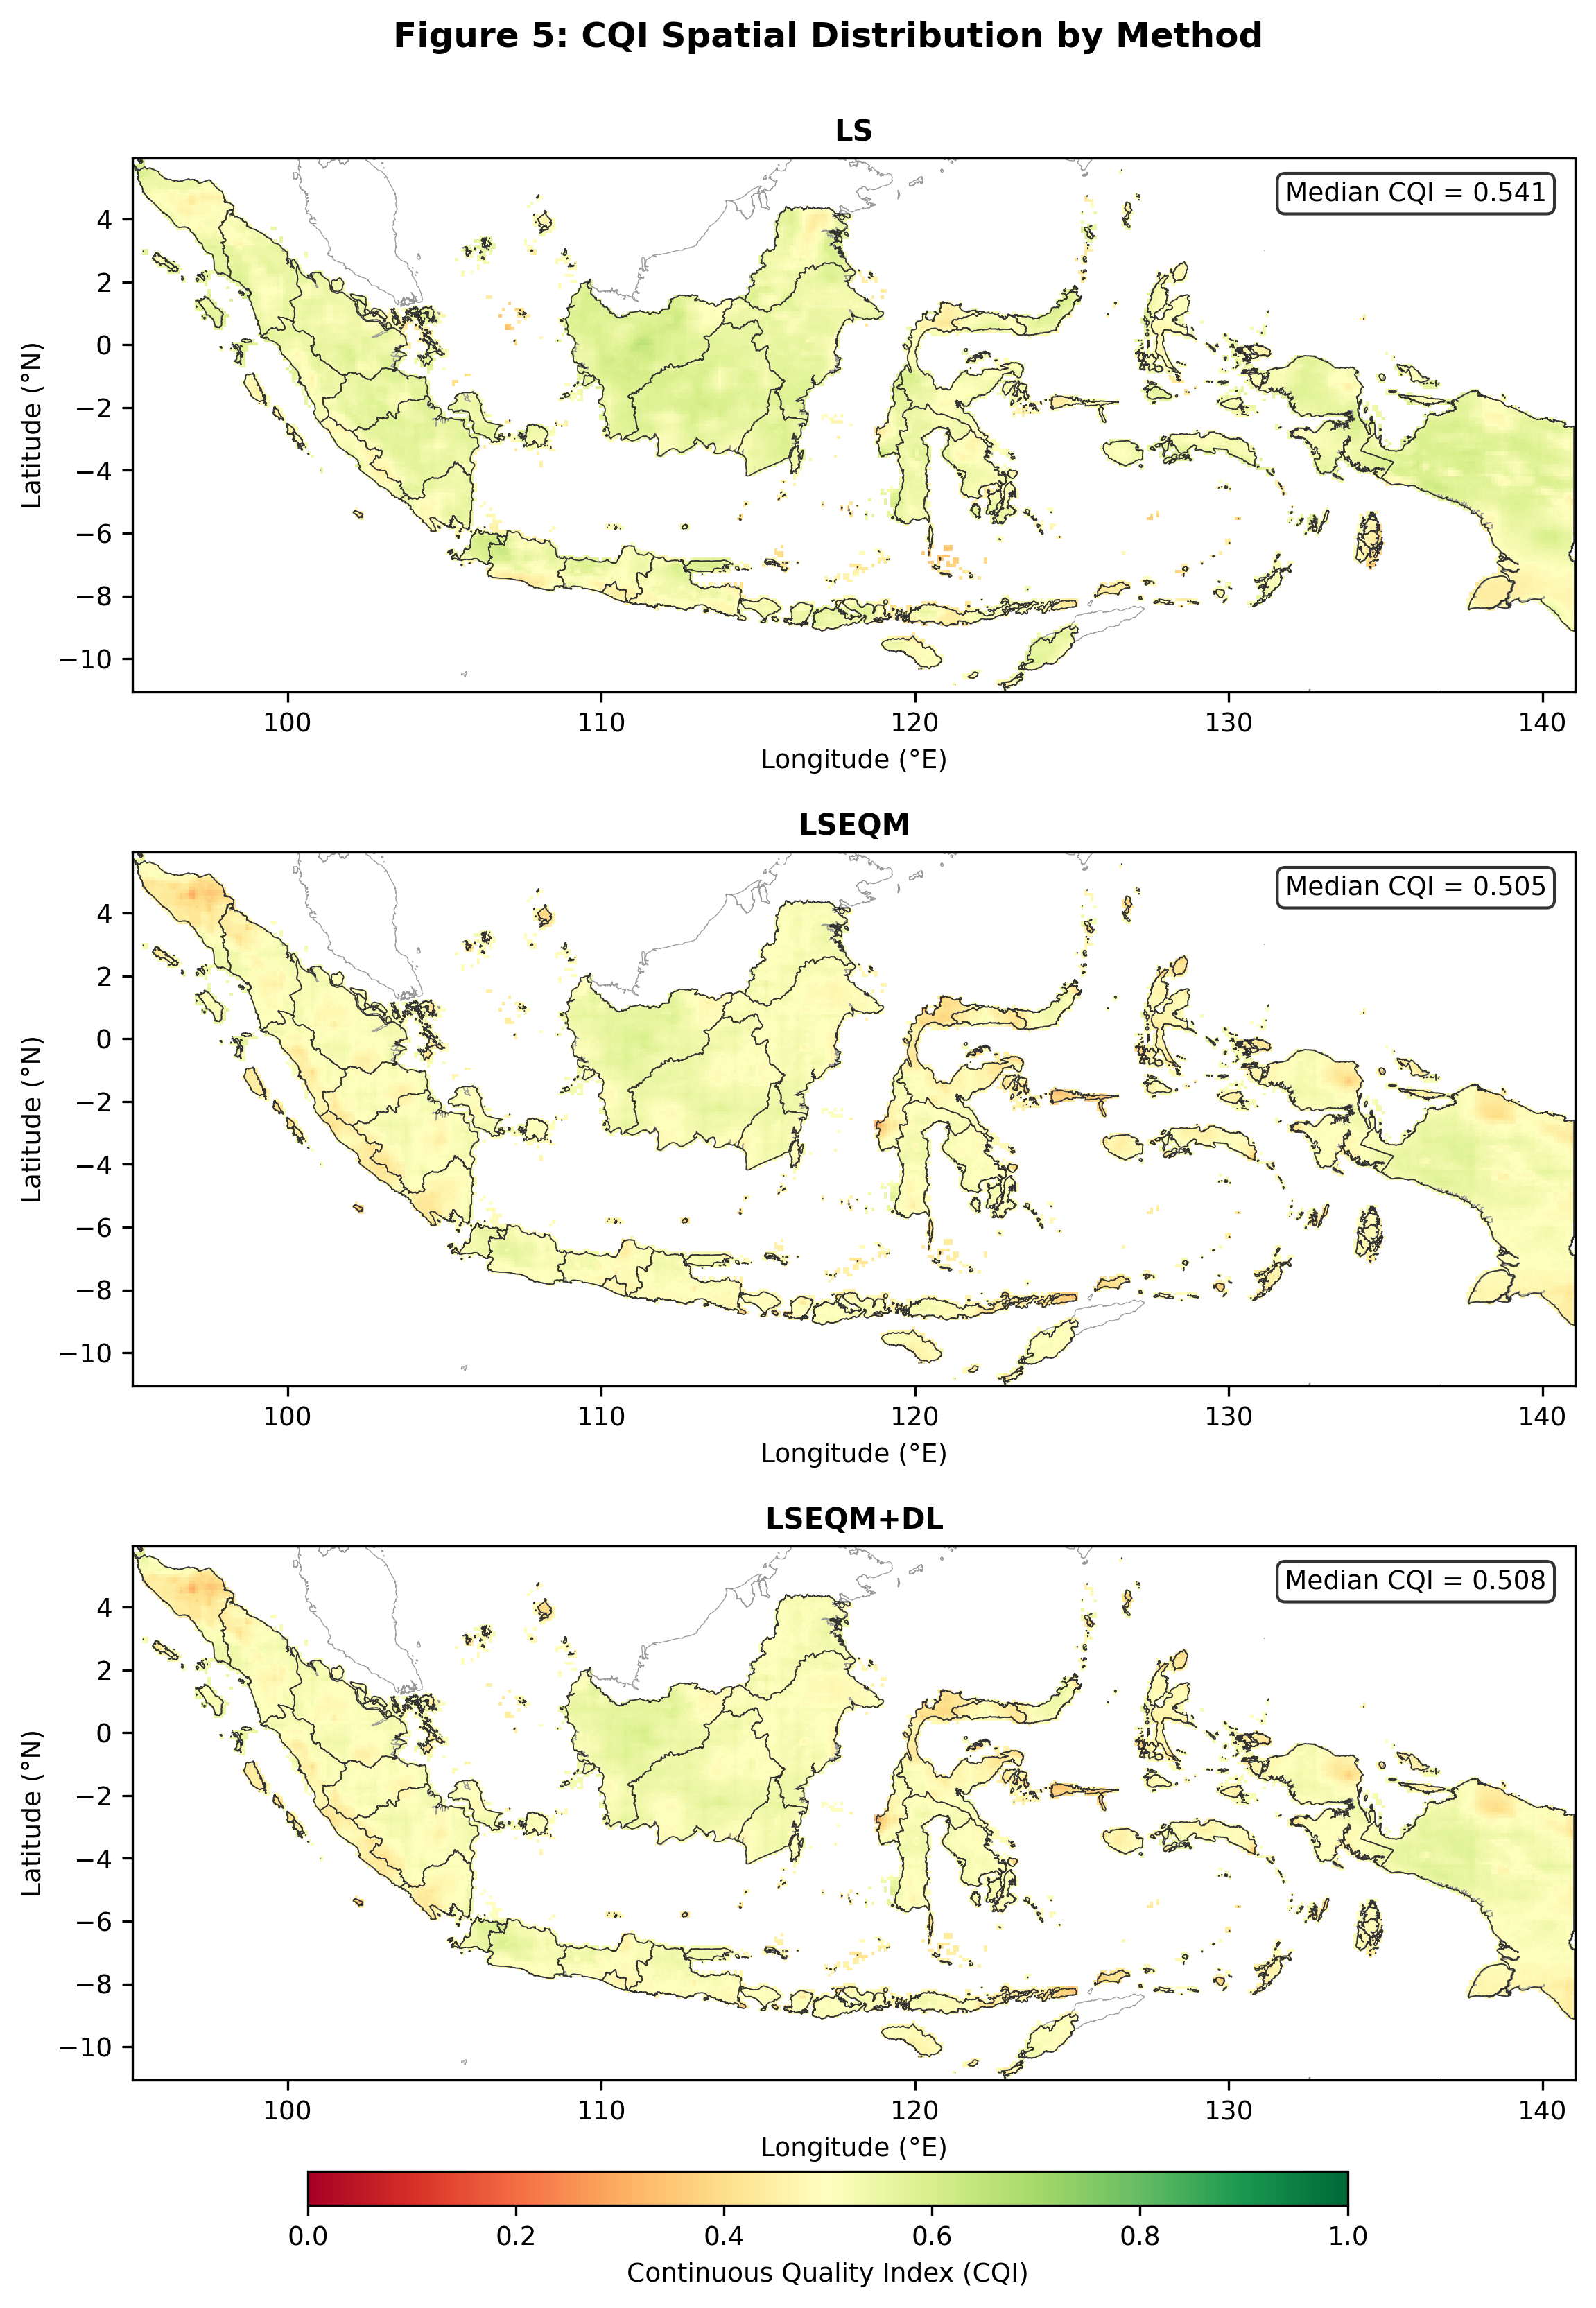

In [27]:
# -- Figure 5: CQI spatial maps -----------------------------------------------

# Load and average CQI across all periods
cqi_maps = {}  # method -> 2D array (lat, lon)
lat_coords = None
lon_coords = None

for method in METHODS:
    cqi_stack = []
    for month, dekad in ALL_PERIODS:
        fpath = quality_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        ds = xr.open_dataset(fpath, decode_timedelta=False)
        if 'continuous_quality' in ds.data_vars:
            cqi_stack.append(ds['continuous_quality'].values)
            if lat_coords is None:
                lat_coords = ds['lat'].values
                lon_coords = ds['lon'].values
        ds.close()
    if cqi_stack:
        cqi_maps[method] = np.nanmean(np.stack(cqi_stack, axis=0), axis=0)
        print(f'{method}: loaded {len(cqi_stack)} periods, '
              f'CQI range [{np.nanmin(cqi_maps[method]):.3f}, '
              f'{np.nanmax(cqi_maps[method]):.3f}]')

extent = [lon_coords.min(), lon_coords.max(),
          lat_coords.min(), lat_coords.max()]

fig, axes = plt.subplots(3, 1, figsize=(10, 11))

for ax, method, mlabel in zip(axes, METHODS, METHOD_LABELS):
    im = ax.imshow(
        cqi_maps[method],
        extent=extent, origin='lower',
        cmap='RdYlGn', vmin=0, vmax=1,
        aspect='auto', interpolation='nearest',
    )
    overlay_boundaries(ax, ADMIN_ADM0, ADMIN_ADM1)
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_title(mlabel, fontweight='bold')
    ax.set_xlabel('Longitude (\u00b0E)')
    ax.set_ylabel('Latitude (\u00b0N)')

    med = np.nanmedian(cqi_maps[method])
    ax.text(0.98, 0.92, f'Median CQI = {med:.3f}',
            transform=ax.transAxes, fontsize=9, ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.subplots_adjust(hspace=0.30, top=0.92, bottom=0.08)
fig.suptitle('Figure 5: CQI Spatial Distribution by Method',
             fontsize=12, fontweight='bold', y=0.98)

cbar_ax = fig.add_axes([0.25, 0.025, 0.5, 0.015])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Continuous Quality Index (CQI)')

save_fig(fig, 'fig05_cqi_spatial.png')
plt.show()


## Step 7 — Figure 6: CQI Improvement

Panel (a): CQI difference map (LSEQM+DL minus LS).    
Panel (b): Categorical classification of LSEQM+DL (Excellent/Good/Fair/Poor).

 Excellent:   0.0% (     0 pixels)
      Good:   0.0% (     2 pixels)
 Fair-High:  60.1% ( 11648 pixels)
  Fair-Low:  38.4% (  7453 pixels)
  Marginal:   1.5% (   289 pixels)
      Poor:   0.0% (     1 pixels)
Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig06_cqi_improvement.png


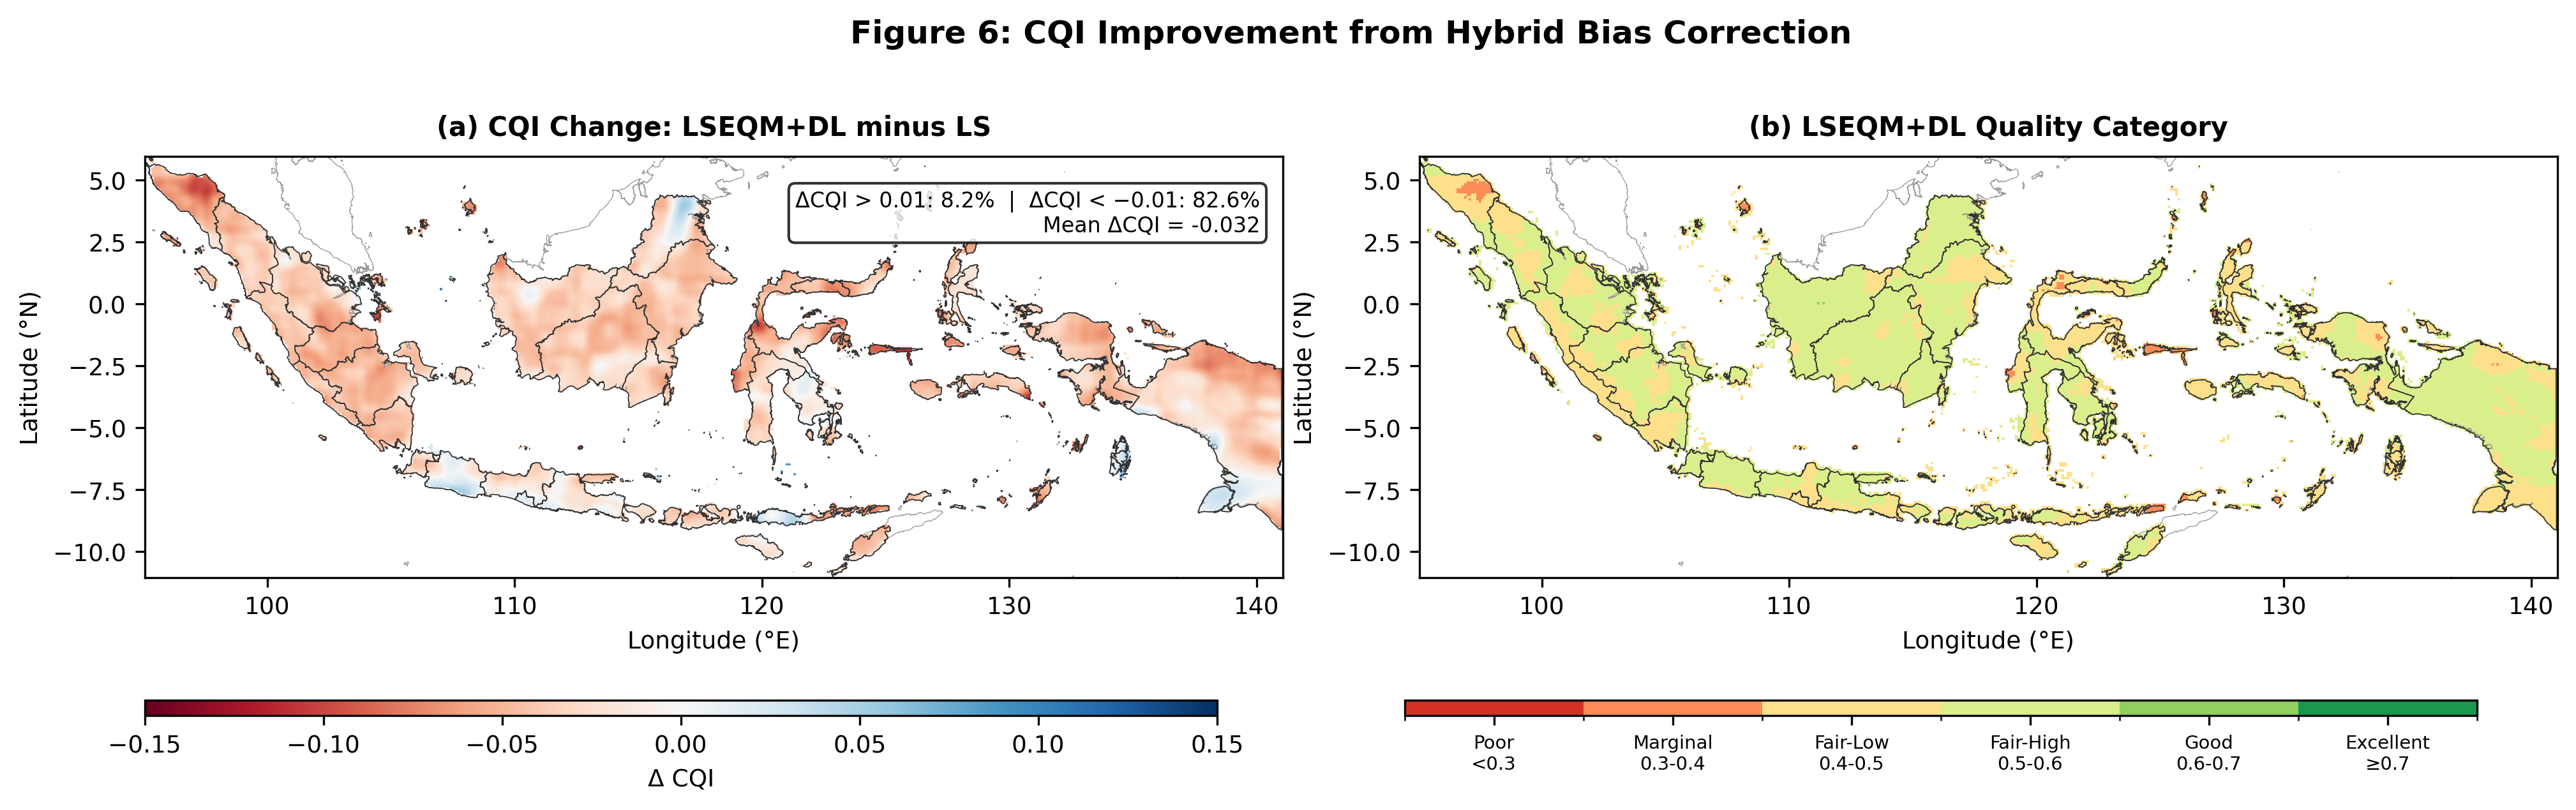

In [28]:
# -- Figure 6: CQI improvement ------------------------------------------------
from scipy.ndimage import gaussian_filter

# CQI difference: LSEQM+DL minus LS
cqi_diff_raw = cqi_maps['lseqmdl'] - cqi_maps['ls']
cqi_dl = cqi_maps['lseqmdl']

# NaN-aware Gaussian smoothing (sigma=1.5) to remove pixel noise
nan_mask = ~np.isfinite(cqi_diff_raw)
cqi_diff_filled = np.where(nan_mask, 0.0, cqi_diff_raw)
weight = np.where(nan_mask, 0.0, 1.0)
smoothed_diff = gaussian_filter(cqi_diff_filled, sigma=1.5)
smoothed_weight = gaussian_filter(weight, sigma=1.5)
smoothed_weight[smoothed_weight == 0] = 1.0
cqi_diff = smoothed_diff / smoothed_weight
cqi_diff[nan_mask] = np.nan

fig = plt.figure(figsize=(14, 4))
gs = fig.add_gridspec(1, 2, wspace=0.12,
                       left=0.05, right=0.95, top=0.88, bottom=0.15)

# Panel (a): Smoothed difference map
ax_a = fig.add_subplot(gs[0])
im_a = ax_a.imshow(
    cqi_diff, extent=extent, origin='lower',
    cmap='RdBu', vmin=-0.15, vmax=0.15,
    aspect='auto', interpolation='bilinear',
)
overlay_boundaries(ax_a, ADMIN_ADM0, ADMIN_ADM1)
ax_a.set_xlim(extent[0], extent[1])
ax_a.set_ylim(extent[2], extent[3])
ax_a.set_title('(a) CQI Change: LSEQM+DL minus LS', fontweight='bold', pad=8)
ax_a.set_xlabel('Longitude (\u00b0E)')
ax_a.set_ylabel('Latitude (\u00b0N)')

total_valid = np.nansum(np.isfinite(cqi_diff_raw))
# Use 0.01 threshold for meaningful change (Option B)
improved = np.nansum(cqi_diff_raw > 0.01)
degraded = np.nansum(cqi_diff_raw < -0.01)
pct_pos = 100.0 * improved / total_valid if total_valid > 0 else 0
pct_neg = 100.0 * degraded / total_valid if total_valid > 0 else 0
mean_dcqi = np.nanmean(cqi_diff_raw)
# Option C (neutral labels) + Option D (mean magnitude)
ax_a.text(0.98, 0.92,
          f'\u0394CQI > 0.01: {pct_pos:.1f}%  |  \u0394CQI < \u22120.01: {pct_neg:.1f}%\n'
          f'Mean \u0394CQI = {mean_dcqi:.3f}',
          transform=ax_a.transAxes, fontsize=8, ha='right', va='top',
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel (b): 6-tier categorical
ax_b = fig.add_subplot(gs[1])
cat_map = np.full_like(cqi_dl, np.nan)
cat_map[cqi_dl >= 0.7] = 6
cat_map[(cqi_dl >= 0.6) & (cqi_dl < 0.7)] = 5
cat_map[(cqi_dl >= 0.5) & (cqi_dl < 0.6)] = 4
cat_map[(cqi_dl >= 0.4) & (cqi_dl < 0.5)] = 3
cat_map[(cqi_dl >= 0.3) & (cqi_dl < 0.4)] = 2
cat_map[(cqi_dl < 0.3) & np.isfinite(cqi_dl)] = 1

cat_cmap = mcolors.ListedColormap([
    '#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850'])
cat_norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5],
                                 cat_cmap.N)
im_b = ax_b.imshow(
    cat_map, extent=extent, origin='lower',
    cmap=cat_cmap, norm=cat_norm,
    aspect='auto', interpolation='nearest',
)
overlay_boundaries(ax_b, ADMIN_ADM0, ADMIN_ADM1)
ax_b.set_xlim(extent[0], extent[1])
ax_b.set_ylim(extent[2], extent[3])
ax_b.set_title('(b) LSEQM+DL Quality Category', fontweight='bold', pad=8)
ax_b.set_xlabel('Longitude (\u00b0E)')
ax_b.set_ylabel('Latitude (\u00b0N)')

# Colorbars placed manually
cbar_ax_a = fig.add_axes([0.05, 0.06, 0.40, 0.02])
cbar_a = fig.colorbar(im_a, cax=cbar_ax_a, orientation='horizontal')
cbar_a.set_label('\u0394 CQI')

cbar_ax_b = fig.add_axes([0.52, 0.06, 0.40, 0.02])
cbar_b = fig.colorbar(im_b, cax=cbar_ax_b, orientation='horizontal',
                       ticks=[1, 2, 3, 4, 5, 6])
cbar_b.ax.set_xticklabels(['Poor\n<0.3', 'Marginal\n0.3-0.4',
                            'Fair-Low\n0.4-0.5', 'Fair-High\n0.5-0.6',
                            'Good\n0.6-0.7', 'Excellent\n\u22650.7'],
                           fontsize=7)

cat_names = {6: 'Excellent', 5: 'Good', 4: 'Fair-High', 3: 'Fair-Low',
             2: 'Marginal', 1: 'Poor'}
for cat_val in [6, 5, 4, 3, 2, 1]:
    n = np.nansum(cat_map == cat_val)
    pct = 100.0 * n / total_valid if total_valid > 0 else 0
    print(f'{cat_names[cat_val]:>10s}: {pct:5.1f}% ({int(n):>6d} pixels)')

fig.suptitle('Figure 6: CQI Improvement from Hybrid Bias Correction',
             fontsize=12, fontweight='bold', y=0.97)

save_fig(fig, 'fig06_cqi_improvement.png')
plt.show()

## Step 8 — Figure 7: CQI Component Box Plots

Four-panel box plots comparing BSQS, DQS, TQS, and CQI across methods.
Whiskers at 5th and 95th percentiles. DQS is expected to show the largest
improvement.

BSQS LS: median = 0.3256
BSQS LSEQM: median = 0.2970
BSQS LSEQM+DL: median = 0.2987
DQS LS: median = 0.6856
DQS LSEQM: median = 0.6560
DQS LSEQM+DL: median = 0.6613
TQS LS: median = 0.6657
TQS LSEQM: median = 0.6480
TQS LSEQM+DL: median = 0.6480
CQI LS: median = 0.5407
CQI LSEQM: median = 0.5073
CQI LSEQM+DL: median = 0.5098
Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig07_component_boxplots.png


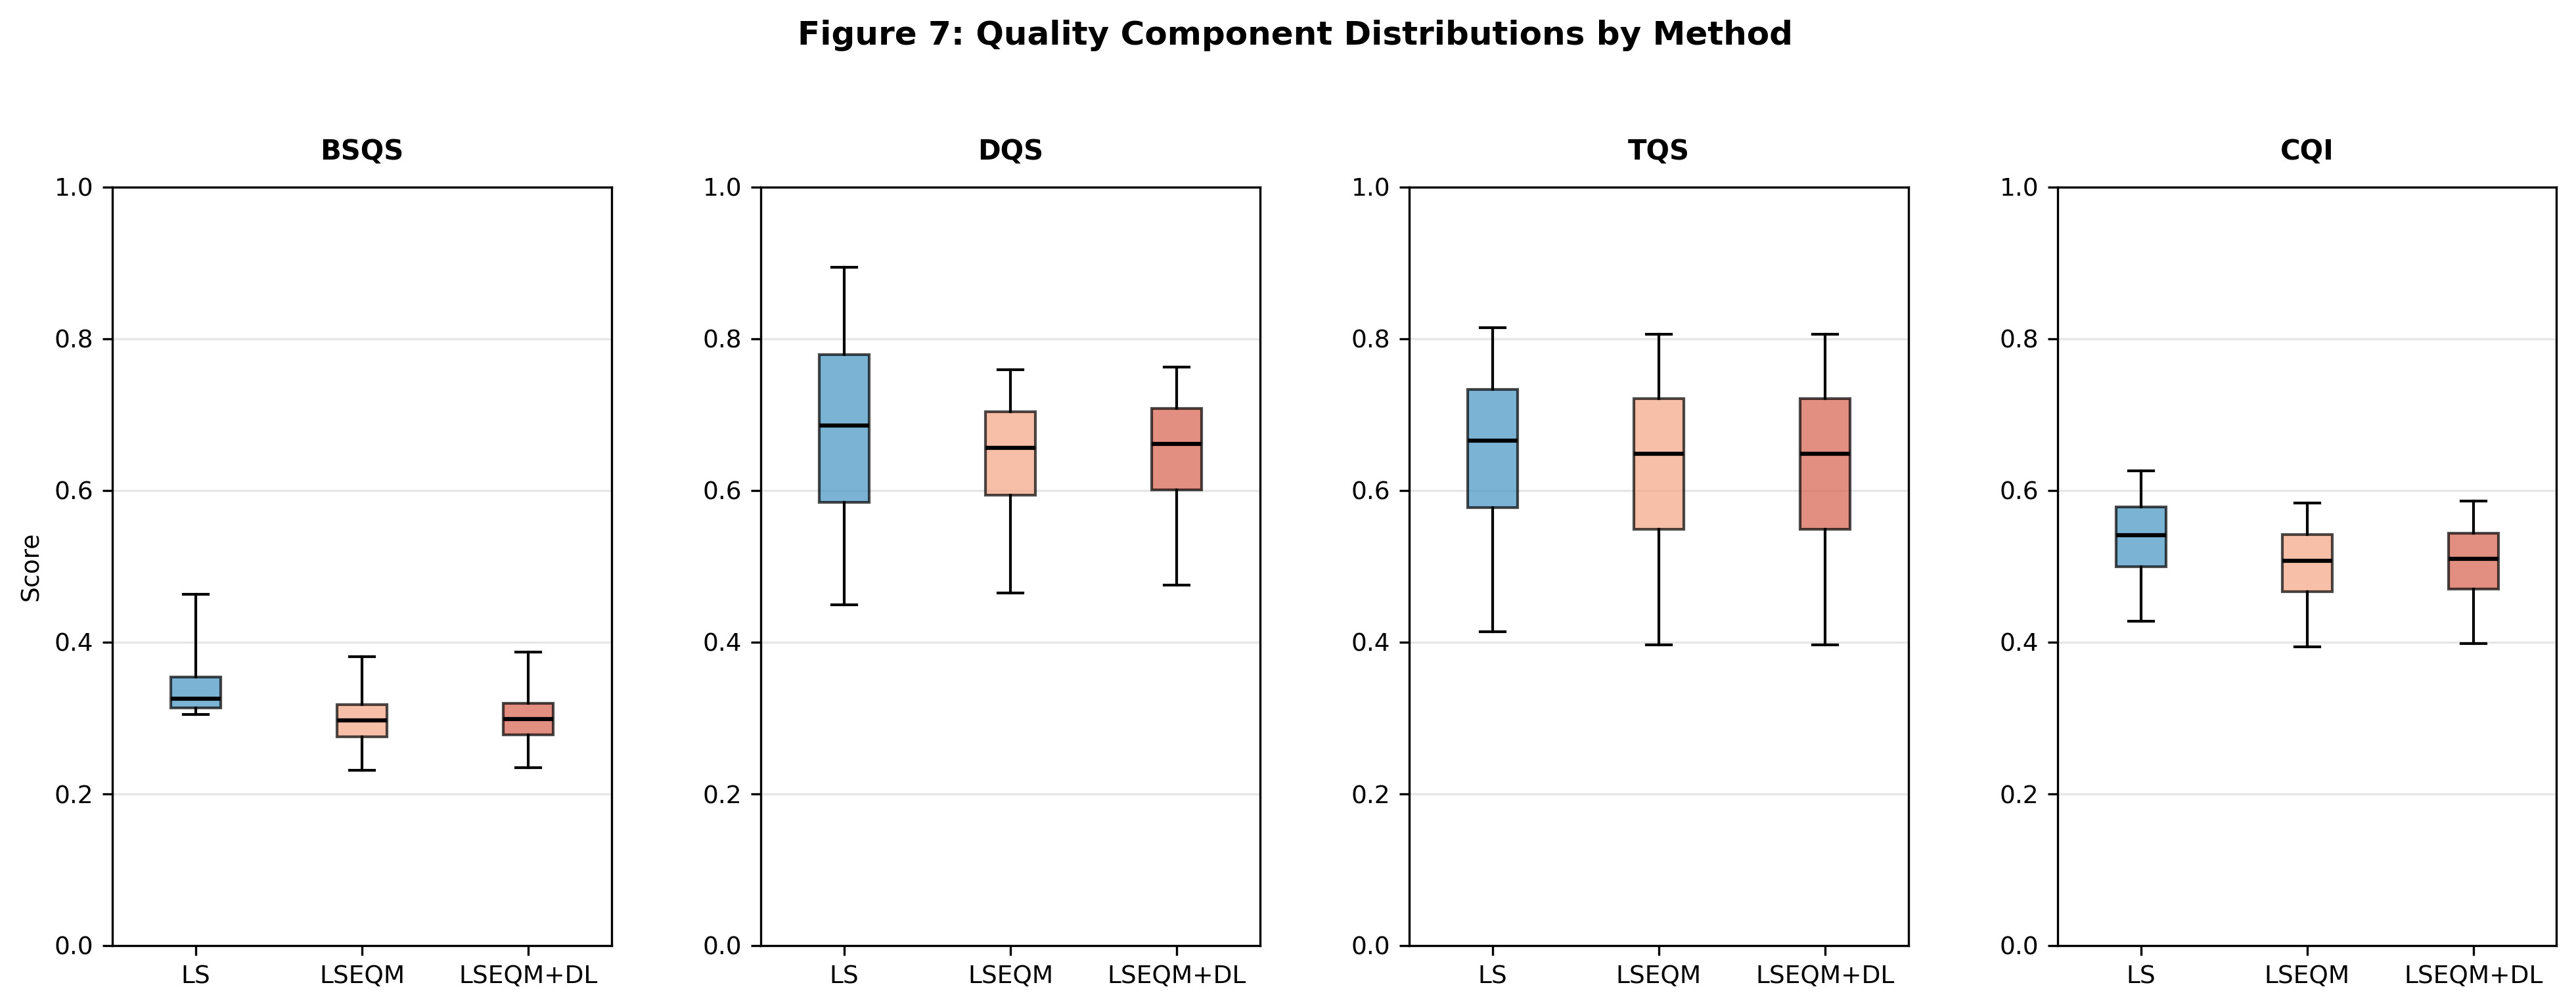

In [29]:
# -- Figure 7: CQI component box plots ----------------------------------------

QUALITY_VARS = [
    ('basic_statistical_quality', 'BSQS'),
    ('distribution_quality', 'DQS'),
    ('temporal_quality', 'TQS'),
    ('continuous_quality', 'CQI'),
]

# Collect all pixel values: {method: {var: 1D array of all pixels x all periods}}
comp_data = {m: {v: [] for v, _ in QUALITY_VARS} for m in METHODS}

for method in METHODS:
    for month, dekad in ALL_PERIODS:
        fpath = quality_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        ds = xr.open_dataset(fpath, decode_timedelta=False)
        for var, _ in QUALITY_VARS:
            if var in ds.data_vars:
                vals = ds[var].values.ravel()
                vals = vals[np.isfinite(vals)]
                comp_data[method][var].append(vals)
        ds.close()

# Concatenate
for method in METHODS:
    for var, _ in QUALITY_VARS:
        if comp_data[method][var]:
            comp_data[method][var] = np.concatenate(comp_data[method][var])
        else:
            comp_data[method][var] = np.array([])

# Plot
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['#4393c3', '#f4a582', '#d6604d']  # LS blue, LSEQM orange, DL red

for ax, (var, label) in zip(axes, QUALITY_VARS):
    bp_data = []
    for method in METHODS:
        arr = comp_data[method][var]
        if len(arr) > 0:
            bp_data.append(arr)
        else:
            bp_data.append(np.array([np.nan]))

    bp = ax.boxplot(
        bp_data,
        labels=METHOD_LABELS,
        whis=(5, 95),
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(label, fontweight='bold', pad=10)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score' if ax == axes[0] else '')
    ax.grid(axis='y', alpha=0.3)

    # Print medians
    for i, (method, mlabel) in enumerate(zip(METHODS, METHOD_LABELS)):
        med = (np.median(comp_data[method][var])
               if len(comp_data[method][var]) > 0 else np.nan)
        print(f'{label} {mlabel}: median = {med:.4f}')

fig.suptitle('Figure 7: Quality Component Distributions by Method',
             fontsize=12, fontweight='bold', y=1.05)
fig.subplots_adjust(wspace=0.3, top=0.88)

save_fig(fig, 'fig07_component_boxplots.png')
plt.show()


## Step 9 — Table 7 + Figure 8: Station Validation

Independent validation against 171 BMKG weather stations. Table 7 shows
three-pillar metrics computed from station-level data (grand median across
all station x dekad observations).

In [30]:
# -- Table 7: Station validation three-pillar metrics -------------------------

# Direct station metrics
STA_DIRECT = [
    'relative_bias', 'stdev_ratio', 'ks_pvalue',
    'pod', 'csi', 'far',
    'pearson_correlation', 'rmse', 'nse',
]

# Ratio pairs from station CSVs
STA_RATIO_PAIRS = {
    'fpd_ratio': ('fpd_test', 'fpd_ref'),
    'mdwp_ratio': ('mdwp_test', 'mdwp_ref'),
    'p95_ratio': ('p95_test', 'p95_ref'),
    'p99_ratio': ('p99_test', 'p99_ref'),
}

all_sta_keys = STA_DIRECT + list(STA_RATIO_PAIRS.keys())

# Collect all station x dekad observations: {method: {metric: [values]}}
sta_data = {m: {k: [] for k in all_sta_keys} for m in METHODS}
station_counts = {m: 0 for m in METHODS}

for method in METHODS:
    for month, dekad in ALL_PERIODS:
        fpath = station_val_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        df = pd.read_csv(fpath)
        station_counts[method] = max(station_counts[method], len(df))

        # Direct metrics
        for v in STA_DIRECT:
            if v in df.columns:
                vals = df[v].dropna().values
                sta_data[method][v].extend(vals.tolist())

        # Ratio metrics
        for ratio_name, (test_col, ref_col) in STA_RATIO_PAIRS.items():
            if test_col in df.columns and ref_col in df.columns:
                mask = df[ref_col].notna() & df[test_col].notna() & (df[ref_col] > 0)
                if mask.any():
                    ratio_vals = (df.loc[mask, test_col] / df.loc[mask, ref_col]).values
                    ratio_vals = ratio_vals[np.isfinite(ratio_vals)]
                    sta_data[method][ratio_name].extend(ratio_vals.tolist())

# Compute grand medians
sta_medians = {}
for method in METHODS:
    sta_medians[method] = {}
    for k in all_sta_keys:
        vals = np.array(sta_data[method][k])
        vals = vals[np.isfinite(vals)]
        sta_medians[method][k] = np.median(vals) if len(vals) > 0 else np.nan

# Print Table 7
print('=' * 72)
print('TABLE 7: Station Validation (171 BMKG stations, grand median)')
print('=' * 72)
print(f'{"Metric":<30} {"Ideal":>6} {"LS":>10} {"LSEQM":>10} {"LSEQM+DL":>10}')
print('-' * 72)

for pillar_name, pillar_metrics in PILLAR_METRICS.items():
    print(f'\n  {pillar_name}')
    print(f'  {"-" * 68}')
    for key, (label, ideal) in pillar_metrics.items():
        vals = [sta_medians[m].get(key, np.nan) for m in METHODS]
        ideal_str = f'{ideal}'
        print(f'  {label:<28} {ideal_str:>6}'
              f' {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

print(f'\n  Temporal Skill (acknowledged limitation)')
print(f'  {"-" * 68}')
for key, (label, ideal) in TEMPORAL_METRICS.items():
    vals = [sta_medians[m].get(key, np.nan) for m in METHODS]
    ideal_str = f'{ideal}'
    print(f'  {label:<28} {ideal_str:>6}'
          f' {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

print('\n' + '=' * 72)
for method, mlabel in zip(METHODS, METHOD_LABELS):
    print(f'{mlabel}: up to {station_counts[method]} stations per dekad')

TABLE 7: Station Validation (171 BMKG stations, grand median)
Metric                          Ideal         LS      LSEQM   LSEQM+DL
------------------------------------------------------------------------

  Value Adjustment
  --------------------------------------------------------------------
  Relative Bias                     0    -0.1139     0.0087    -0.0057
  Std. Dev. Ratio                 1.0     0.7148     1.0272     0.9994

  Distribution Alignment
  --------------------------------------------------------------------
  KS p-value (%)                  100     0.0001     0.1907     0.1907
  Wet-Day Freq. Ratio             1.0     1.2105     0.9552     0.9545
  Mean Wet-Day Precip Ratio       1.0     0.7118     1.0602     1.0456

  Extreme Preservation
  --------------------------------------------------------------------
  Q95 Ratio                       1.0     0.7375     1.0726     1.0478
  Q99 Ratio                       1.0     0.7094     1.0487     1.0112

  Event Detec

Stations with stdev_ratio data: 171
Stdev ratio range: [0.470, 3.416]
Median stdev ratio: 1.062
Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig08_station_validation.png


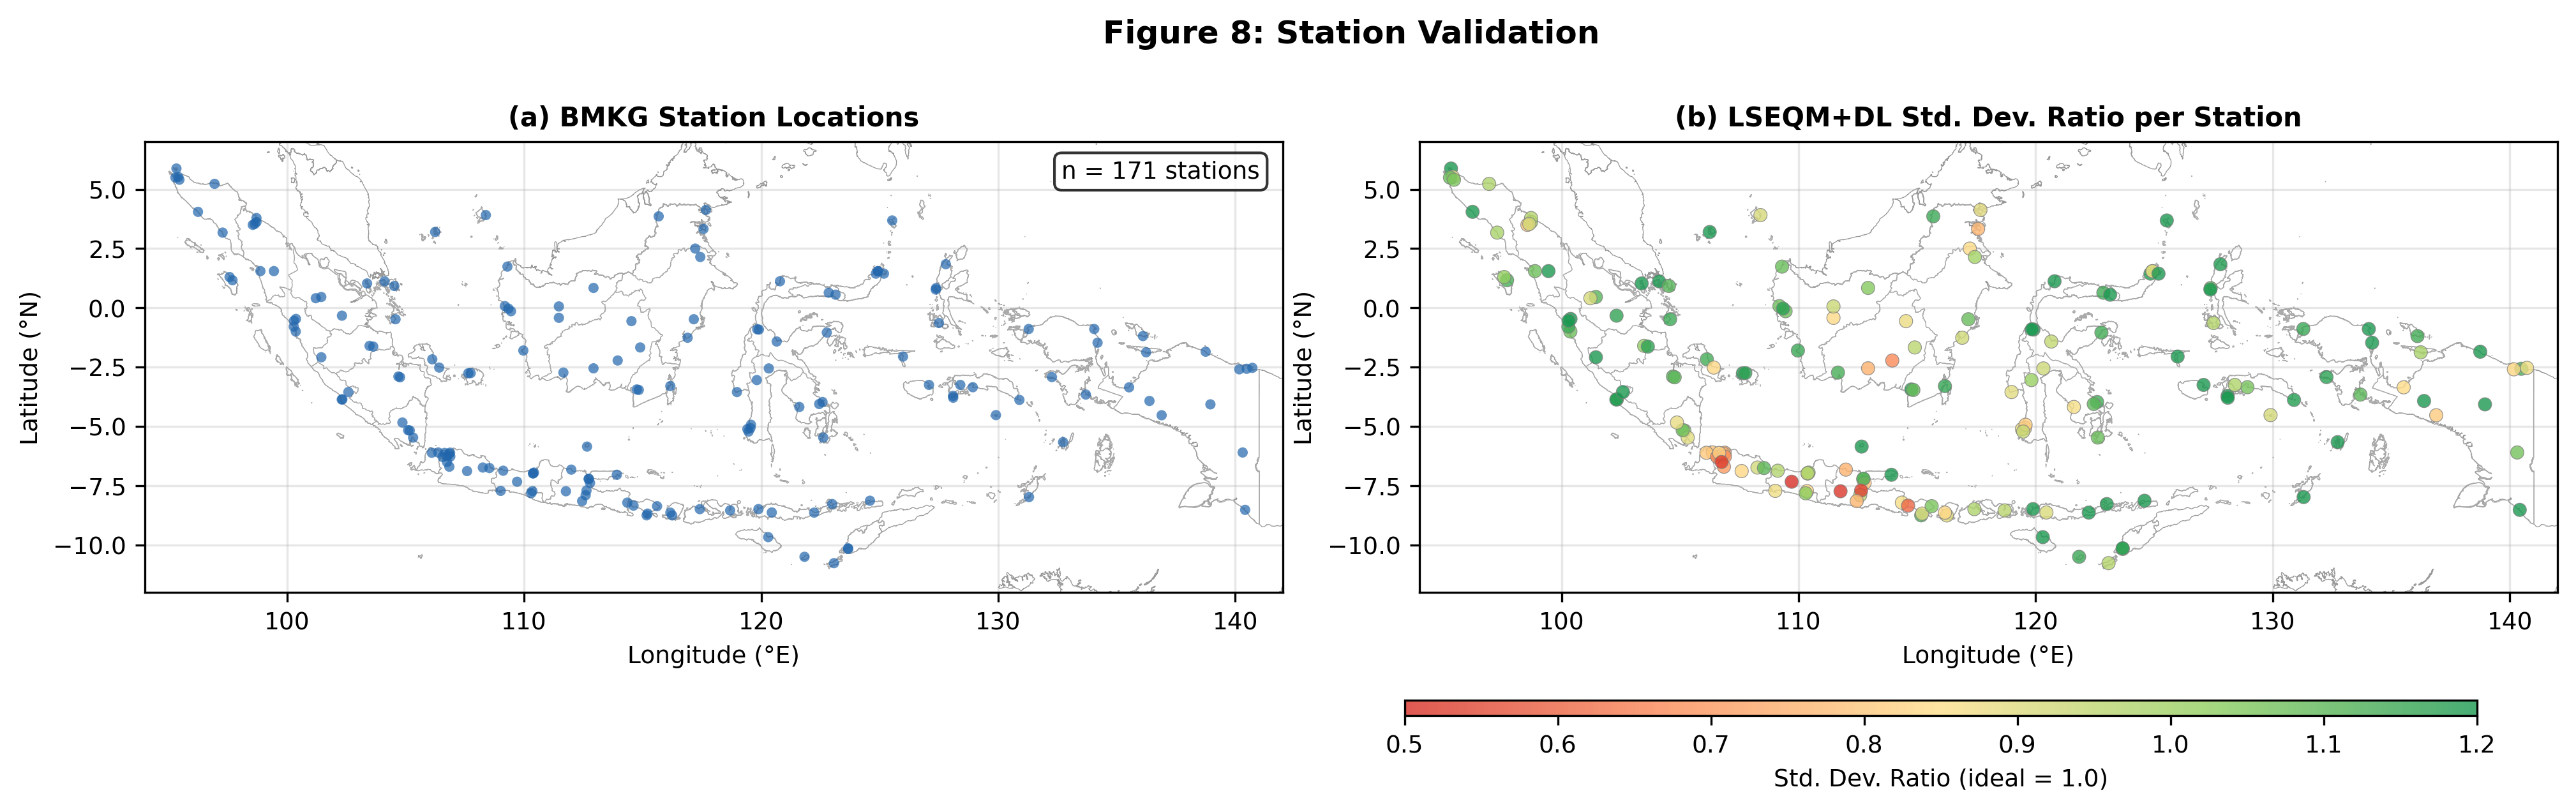

In [31]:
# -- Figure 8: Station validation map -----------------------------------------

# Collect per-station stdev_ratio for LSEQM+DL, averaged across dekads
station_stdev = {}
station_info = {}

for month, dekad in ALL_PERIODS:
    fpath = station_val_path('lseqmdl', month, dekad)
    if not os.path.exists(fpath):
        continue
    df = pd.read_csv(fpath)
    for _, row in df.iterrows():
        sid = row['station_id']
        if sid not in station_stdev:
            station_stdev[sid] = []
            station_info[sid] = {
                'lon': row['Lon'], 'lat': row['Lat'],
                'name': row.get('Station', ''),
            }
        val = row.get('stdev_ratio', np.nan)
        if np.isfinite(val):
            station_stdev[sid].append(val)

sta_lons, sta_lats, sta_vals = [], [], []
for sid in station_stdev:
    vals = station_stdev[sid]
    if len(vals) > 0:
        sta_lons.append(station_info[sid]['lon'])
        sta_lats.append(station_info[sid]['lat'])
        sta_vals.append(np.mean(vals))

sta_lons = np.array(sta_lons)
sta_lats = np.array(sta_lats)
sta_vals = np.array(sta_vals)

print(f'Stations with stdev_ratio data: {len(sta_vals)}')
print(f'Stdev ratio range: [{sta_vals.min():.3f}, {sta_vals.max():.3f}]')
print(f'Median stdev ratio: {np.median(sta_vals):.3f}')

xlim = (94, 142)
ylim = (-12, 7)

fig = plt.figure(figsize=(14, 4))
gs = fig.add_gridspec(1, 2, wspace=0.12,
                       left=0.05, right=0.95, top=0.88, bottom=0.15)

# Panel (a): Station locations
ax_a = fig.add_subplot(gs[0])
overlay_boundaries(ax_a, ADMIN_ADM0, ADMIN_ADM1, adm1_color='#aaaaaa', adm1_lw=0.3)
ax_a.scatter(sta_lons, sta_lats, s=15, c='#2166ac', alpha=0.7,
             edgecolors='none', zorder=5)
ax_a.set_xlim(xlim)
ax_a.set_ylim(ylim)
ax_a.set_title('(a) BMKG Station Locations', fontweight='bold')
ax_a.set_xlabel('Longitude (\u00b0E)')
ax_a.set_ylabel('Latitude (\u00b0N)')
ax_a.set_aspect('equal')
ax_a.grid(alpha=0.3)
ax_a.text(0.98, 0.92, f'n = {len(sta_vals)} stations',
          transform=ax_a.transAxes, fontsize=9, ha='right',
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel (b): Per-station stdev_ratio
ax_b = fig.add_subplot(gs[1])
overlay_boundaries(ax_b, ADMIN_ADM0, ADMIN_ADM1, adm1_color='#aaaaaa', adm1_lw=0.3)
cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    'stdev_ratio', ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850'],
    N=256)
sc = ax_b.scatter(
    sta_lons, sta_lats,
    c=sta_vals, cmap=cmap_custom, vmin=0.5, vmax=1.2,
    s=25, alpha=0.8, edgecolors='grey', linewidths=0.3, zorder=5,
)
ax_b.set_xlim(xlim)
ax_b.set_ylim(ylim)
ax_b.set_title('(b) LSEQM+DL Std. Dev. Ratio per Station', fontweight='bold')
ax_b.set_xlabel('Longitude (\u00b0E)')
ax_b.set_ylabel('Latitude (\u00b0N)')
ax_b.set_aspect('equal')
ax_b.grid(alpha=0.3)

# Colorbar placed manually — does NOT steal space from panel (b)
cbar_ax = fig.add_axes([0.52, 0.06, 0.40, 0.02])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Std. Dev. Ratio (ideal = 1.0)')

fig.suptitle('Figure 8: Station Validation',
             fontsize=12, fontweight='bold', y=0.97)

save_fig(fig, 'fig08_station_validation.png')
plt.show()

## Step 10 — Figure 9: WMO Multi-Threshold Verification

POD, CSI, and ETS vs precipitation threshold (1, 5, 10, 20, 50, 100, 150 mm).
Lines for each method with IQR shading. Log x-axis for threshold.

Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig09_multi_threshold.png


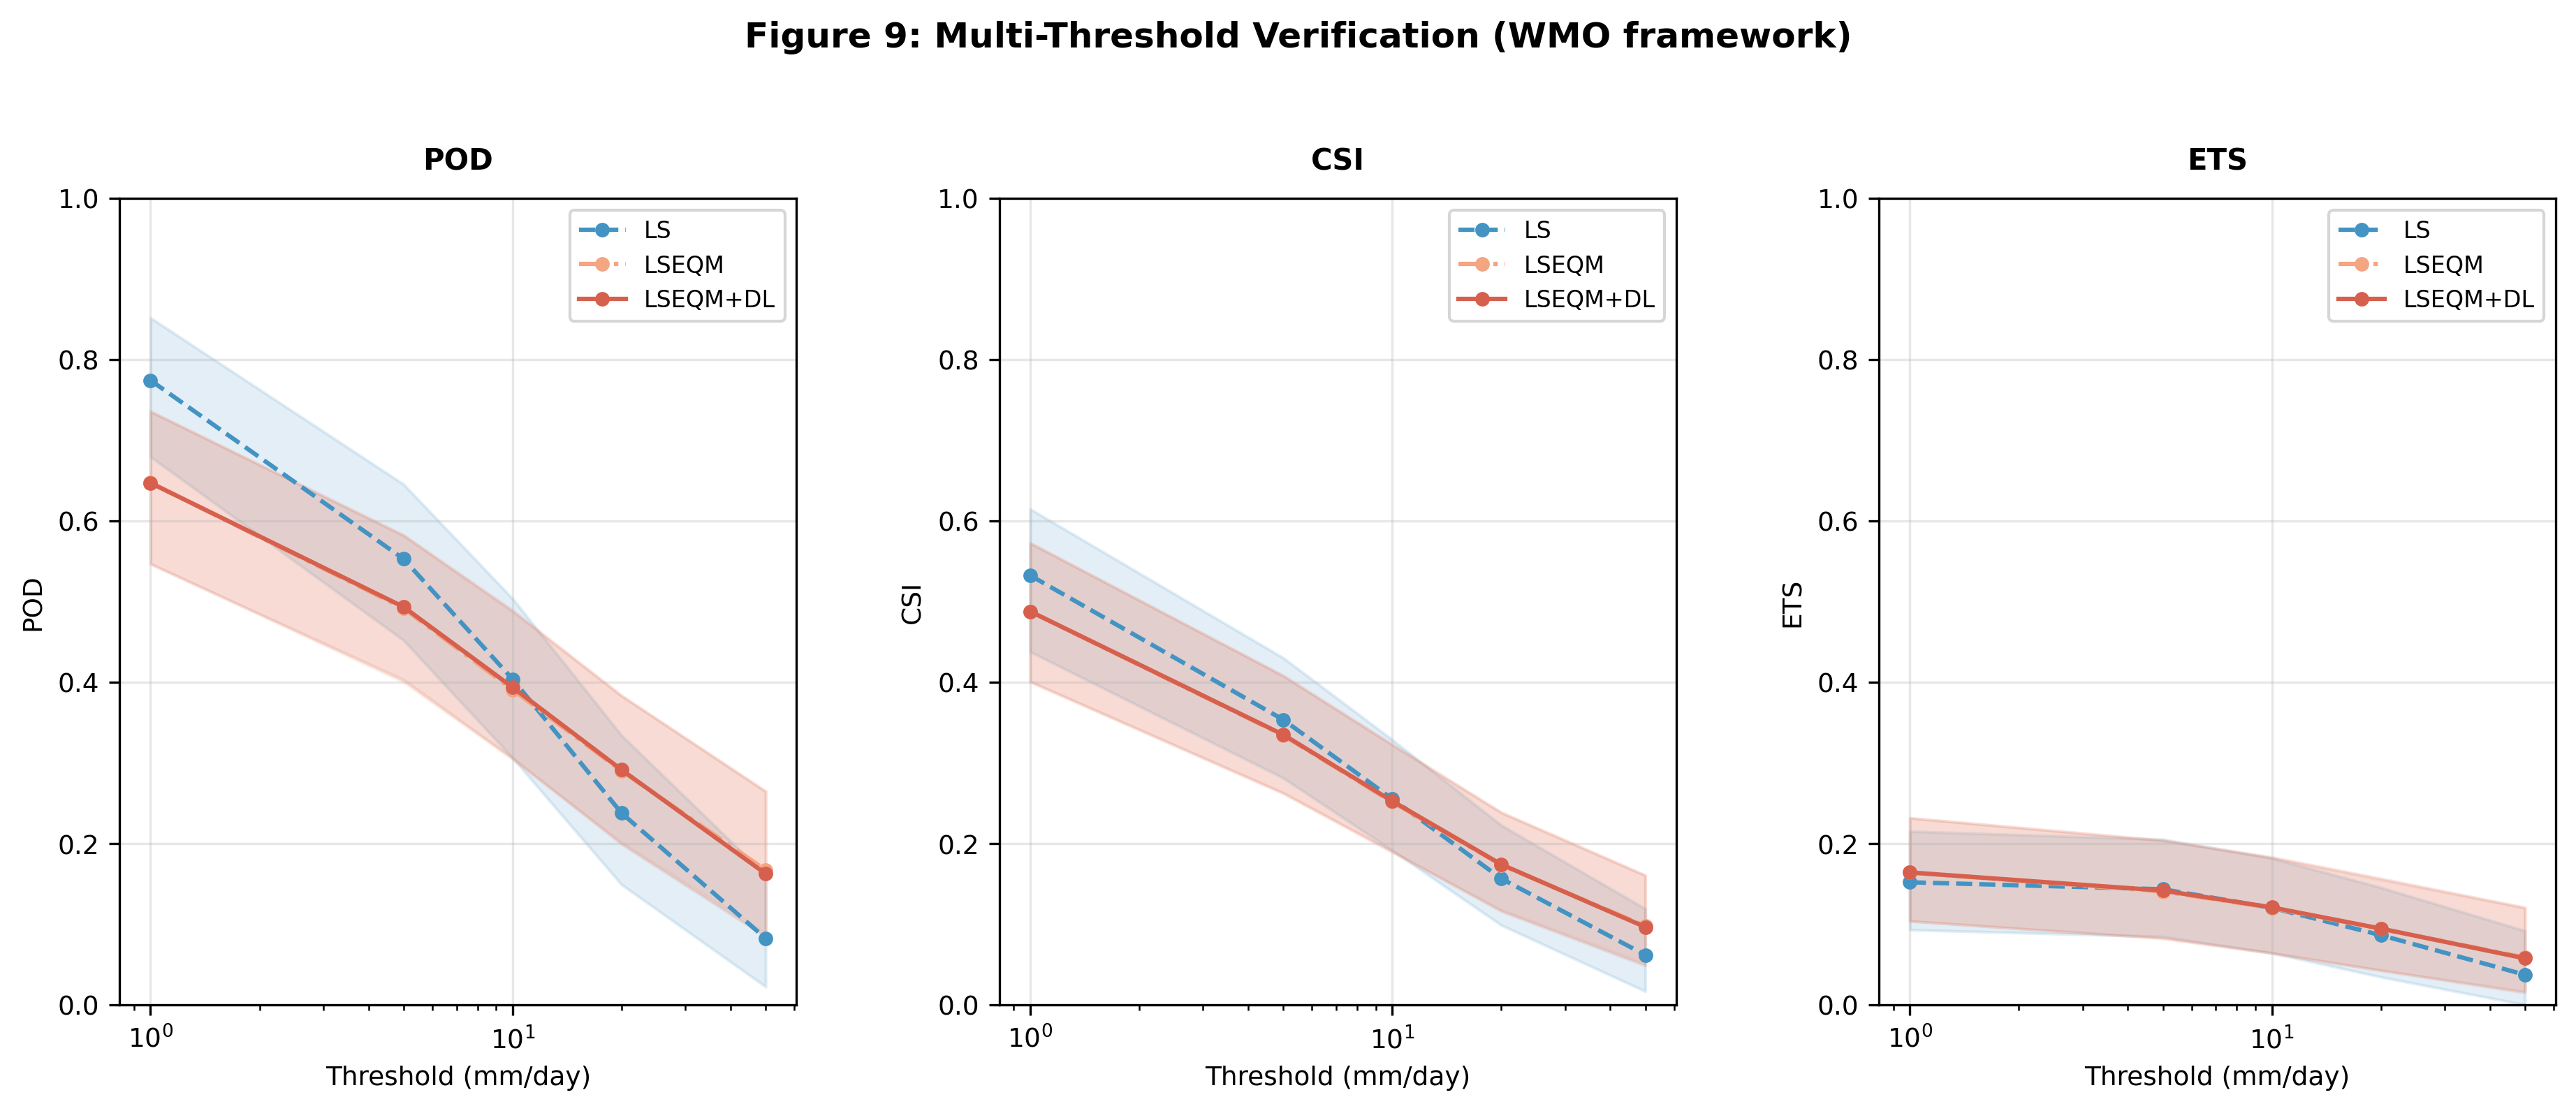

In [32]:
# -- Figure 9: Multi-threshold verification -----------------------------------

# Collect multi-threshold data across all dekads
# Structure: {method: {threshold: {metric: [values across dekads]}}}
mt_metrics = ['pod', 'csi', 'ets']
mt_data = {m: {} for m in METHODS}

for method in METHODS:
    for month, dekad in ALL_PERIODS:
        fpath = multi_threshold_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        df = pd.read_csv(fpath)
        for _, row in df.iterrows():
            thr = row['threshold_mm']
            if thr not in mt_data[method]:
                mt_data[method][thr] = {k: {'median': [], 'p25': [], 'p75': []}
                                        for k in mt_metrics}
            for metric in mt_metrics:
                med_col = f'{metric}_median'
                p25_col = f'{metric}_p25'
                p75_col = f'{metric}_p75'
                if med_col in df.columns:
                    mt_data[method][thr][metric]['median'].append(row[med_col])
                if p25_col in df.columns:
                    mt_data[method][thr][metric]['p25'].append(row[p25_col])
                if p75_col in df.columns:
                    mt_data[method][thr][metric]['p75'].append(row[p75_col])

# Plot
metric_labels = {'pod': 'POD', 'csi': 'CSI', 'ets': 'ETS'}
method_colors = {'ls': '#4393c3', 'lseqm': '#f4a582', 'lseqmdl': '#d6604d'}
method_styles = {'ls': '--', 'lseqm': '-.', 'lseqmdl': '-'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, mt_metrics):
    for method, mlabel in zip(METHODS, METHOD_LABELS):
        if not mt_data[method]:
            continue
        thresholds = sorted(mt_data[method].keys())
        med_vals = []
        p25_vals = []
        p75_vals = []
        for thr in thresholds:
            m_list = mt_data[method][thr][metric]['median']
            q25_list = mt_data[method][thr][metric]['p25']
            q75_list = mt_data[method][thr][metric]['p75']
            med_vals.append(np.mean(m_list) if m_list else np.nan)
            p25_vals.append(np.mean(q25_list) if q25_list else np.nan)
            p75_vals.append(np.mean(q75_list) if q75_list else np.nan)

        ax.plot(thresholds, med_vals,
                color=method_colors[method],
                linestyle=method_styles[method],
                marker='o', markersize=4,
                label=mlabel, linewidth=1.5)
        ax.fill_between(thresholds, p25_vals, p75_vals,
                        color=method_colors[method], alpha=0.15)

    ax.set_xscale('log')
    ax.set_title(metric_labels[metric], fontweight='bold', pad=10)
    ax.set_xlabel('Threshold (mm/day)')
    ax.set_ylabel(metric_labels[metric])
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('Figure 9: Multi-Threshold Verification (WMO framework)',
             fontsize=12, fontweight='bold', y=1.05)
fig.subplots_adjust(wspace=0.3, top=0.88)

save_fig(fig, 'fig09_multi_threshold.png')
plt.show()


## Step 11 — Figure 10: Confidence Mask Analysis

Panel (a): Confidence mask spatial map.
Panel (b): CQI improvement (LSEQM+DL minus LSEQM) binned by confidence quintile.

Confidence mask: median=0.002, mean=0.028
  Zero confidence: 20353 pixels (25.8%)
  Full confidence: 0 pixels (0.0%)
  Confidence 0-0.2: n=18329, median dCQI=0.0016
  Confidence 0.2-0.4: n=930, median dCQI=0.0105
  Confidence 0.4-0.6: n=102, median dCQI=0.0172
  Confidence 0.6-0.8: n=32, median dCQI=0.0318
  Confidence 0.8-1.0: n=0
Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig10_confidence_mask.png


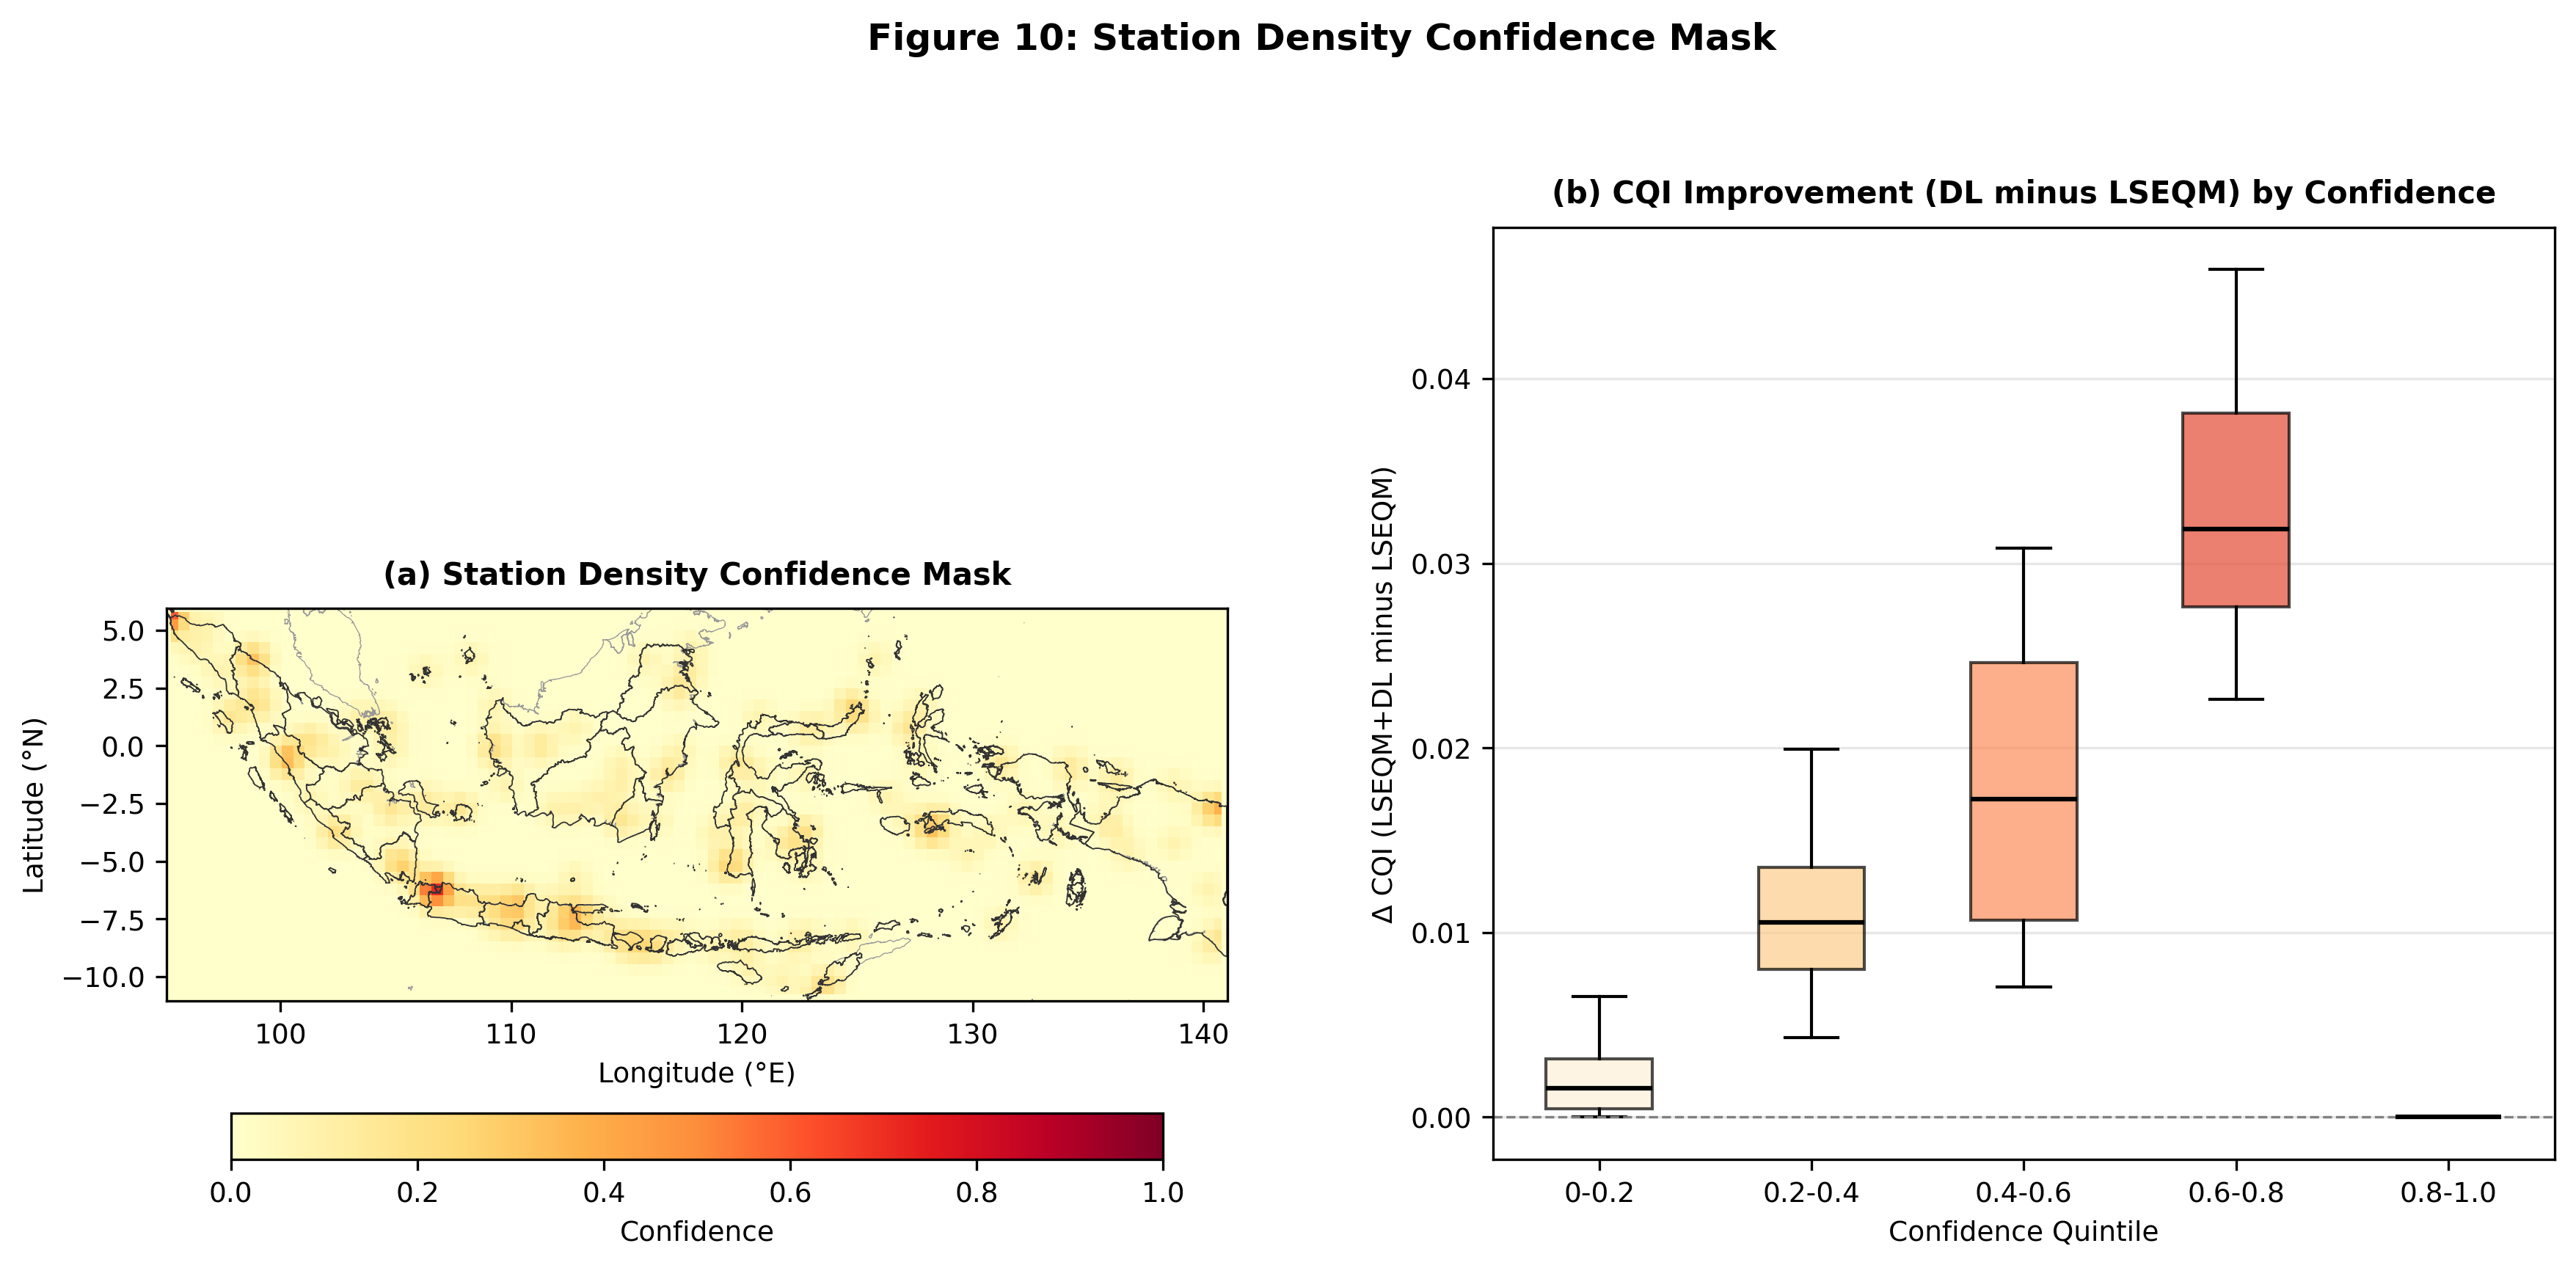

In [33]:
# -- Figure 10: Confidence mask analysis ----------------------------------------

conf_mask_path = os.path.join(OUTPUT_DIR, 'station_density',
                               'confidence_mask_station_density.nc4')
conf_ds = xr.open_dataset(conf_mask_path, decode_timedelta=False)
conf_arr = conf_ds['confidence'].values
conf_lat = conf_ds['lat'].values
conf_lon = conf_ds['lon'].values
conf_ds.close()

cqi_lseqm = cqi_maps.get('lseqm', None)
cqi_lseqmdl = cqi_maps.get('lseqmdl', None)
cqi_improvement = None
if cqi_lseqm is not None and cqi_lseqmdl is not None:
    cqi_improvement = cqi_lseqmdl - cqi_lseqm

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel (a): Confidence mask map
ax = axes[0]
conf_extent = [conf_lon.min(), conf_lon.max(),
               conf_lat.min(), conf_lat.max()]
im_a = ax.imshow(
    conf_arr, extent=conf_extent, origin='lower',
    cmap='YlOrRd', vmin=0, vmax=1,
    aspect='auto', interpolation='nearest',
)
overlay_boundaries(ax, ADMIN_ADM0, ADMIN_ADM1)
ax.set_xlim(conf_extent[0], conf_extent[1])
ax.set_ylim(conf_extent[2], conf_extent[3])
ax.set_title('(a) Station Density Confidence Mask', fontweight='bold', pad=8)
ax.set_xlabel('Longitude (\u00b0E)')
ax.set_ylabel('Latitude (\u00b0N)')
cbar_a = fig.colorbar(im_a, ax=ax, orientation='horizontal',
                       fraction=0.05, pad=0.12)
cbar_a.set_label('Confidence')

valid_conf = conf_arr[np.isfinite(conf_arr)]
print(f'Confidence mask: median={np.median(valid_conf):.3f}, '
      f'mean={np.mean(valid_conf):.3f}')
print(f'  Zero confidence: {np.sum(valid_conf == 0)} pixels '
      f'({100 * np.sum(valid_conf == 0) / len(valid_conf):.1f}%)')
print(f'  Full confidence: {np.sum(valid_conf >= 1.0)} pixels '
      f'({100 * np.sum(valid_conf >= 1.0) / len(valid_conf):.1f}%)')

# Panel (b): CQI improvement by confidence quintile
ax = axes[1]
if cqi_improvement is not None:
    conf_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    bin_labels = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
    bp_data_bins = []

    for i in range(len(conf_bins) - 1):
        lo, hi = conf_bins[i], conf_bins[i + 1]
        if i == len(conf_bins) - 2:
            mask_bin = ((conf_arr >= lo) & (conf_arr <= hi)
                        & np.isfinite(cqi_improvement))
        else:
            mask_bin = ((conf_arr >= lo) & (conf_arr < hi)
                        & np.isfinite(cqi_improvement))
        vals = cqi_improvement[mask_bin]
        bp_data_bins.append(vals if len(vals) > 0 else np.array([0.0]))
        if len(vals) > 0:
            print(f'  Confidence {bin_labels[i]}: n={len(vals)}, '
                  f'median dCQI={np.median(vals):.4f}')
        else:
            print(f'  Confidence {bin_labels[i]}: n=0')

    bp = ax.boxplot(
        bp_data_bins, labels=bin_labels, whis=(5, 95),
        showfliers=False, patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
    )
    colors_q = ['#fef0d9', '#fdcc8a', '#fc8d59', '#e34a33', '#b30000']
    for patch, c in zip(bp['boxes'], colors_q):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)

    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_title('(b) CQI Improvement (DL minus LSEQM) by Confidence',
                 fontweight='bold', pad=8)
    ax.set_xlabel('Confidence Quintile')
    ax.set_ylabel('\u0394 CQI (LSEQM+DL minus LSEQM)')
    ax.grid(axis='y', alpha=0.3)
else:
    ax.text(0.5, 0.5, 'CQI data not available', transform=ax.transAxes,
            ha='center', va='center')

fig.suptitle('Figure 10: Station Density Confidence Mask',
             fontsize=12, fontweight='bold', y=1.05)
fig.subplots_adjust(wspace=0.25, top=0.88)

save_fig(fig, 'fig10_confidence_mask.png')
plt.show()


## Step 12 — Supplementary: Wet vs Dry Season

Split 36 dekads into wet (Oct-Mar) and dry (Apr-Sep) seasons. Compare
three-pillar metrics for each season.

In [34]:
# -- Supplementary: Wet vs Dry season comparison ------------------------------

season_periods = {
    'Wet (Oct-Mar)': [(m, d) for m, d in ALL_PERIODS if m in WET_MONTHS],
    'Dry (Apr-Sep)': [(m, d) for m, d in ALL_PERIODS if m in DRY_MONTHS],
}

all_keys = DIRECT_VARS + list(RATIO_PAIRS.keys())
seasonal_means = {}  # {season: {method: {metric: mean}}}

for season_name, periods in season_periods.items():
    seasonal_means[season_name] = {}
    for method in METHODS:
        accum = {k: [] for k in all_keys}
        for month, dekad in periods:
            fpath = metrics_path(method, month, dekad)
            if not os.path.exists(fpath):
                continue
            ds = xr.open_dataset(fpath, decode_timedelta=False)
            medians = compute_spatial_medians(ds, DIRECT_VARS)
            ratio_m = compute_ratio_medians(ds, RATIO_PAIRS)
            medians.update(ratio_m)
            for k in all_keys:
                val = medians.get(k, np.nan)
                if np.isfinite(val):
                    accum[k].append(val)
            ds.close()

        seasonal_means[season_name][method] = {
            k: np.mean(accum[k]) if accum[k] else np.nan
            for k in all_keys
        }

# Print seasonal comparison
print('=' * 80)
print('SUPPLEMENTARY: Wet vs Dry Season Comparison')
print('=' * 80)

display_metrics = [
    ('relative_bias', 'Relative Bias'),
    ('stdev_ratio', 'Std. Dev. Ratio'),
    ('ks_pvalue', 'KS p-value (%)'),
    ('fpd_ratio', 'Wet-Day Freq. Ratio'),
    ('p95_ratio', 'Q95 Ratio'),
    ('p99_ratio', 'Q99 Ratio'),
    ('pod', 'POD'),
    ('csi', 'CSI'),
    ('pearson_correlation', 'Pearson Corr'),
    ('rmse', 'RMSE (mm/day)'),
]

for season_name in season_periods:
    n_periods = len(season_periods[season_name])
    print(f'\n  {season_name} ({n_periods} dekads)')
    print(f'  {"Metric":<25} {"LS":>10} {"LSEQM":>10} {"LSEQM+DL":>10}')
    print(f'  {"-" * 57}')
    for key, label in display_metrics:
        vals = [seasonal_means[season_name][m].get(key, np.nan) for m in METHODS]
        print(f'  {label:<25} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}')

print('\n' + '=' * 80)

SUPPLEMENTARY: Wet vs Dry Season Comparison

  Wet (Oct-Mar) (18 dekads)
  Metric                            LS      LSEQM   LSEQM+DL
  ---------------------------------------------------------
  Relative Bias                 0.0001     0.0699     0.0650
  Std. Dev. Ratio               0.9569     1.1582     1.1469
  KS p-value (%)                0.0756     0.0000     0.0000
  Wet-Day Freq. Ratio           1.0532     0.9576     0.9575
  Q95 Ratio                     0.9382     1.1746     1.1650
  Q99 Ratio                     0.9556     1.2081     1.1925
  POD                           0.8016     0.7358     0.7358
  CSI                           0.6245     0.6036     0.6036
  Pearson Corr                  0.3242     0.3251     0.3272
  RMSE (mm/day)                14.0454    15.2146    15.0947

  Dry (Apr-Sep) (18 dekads)
  Metric                            LS      LSEQM   LSEQM+DL
  ---------------------------------------------------------
  Relative Bias                -0.0000     0.0

## Step 13 — Supplementary: Per-Month Temporal Stability

Plot key metrics across the 12 months to check for temporal stability of
corrections.

Saved: /content/drive/MyDrive/hybrid-bias-correction/data/output/figures/paper/fig11_temporal_stability.png


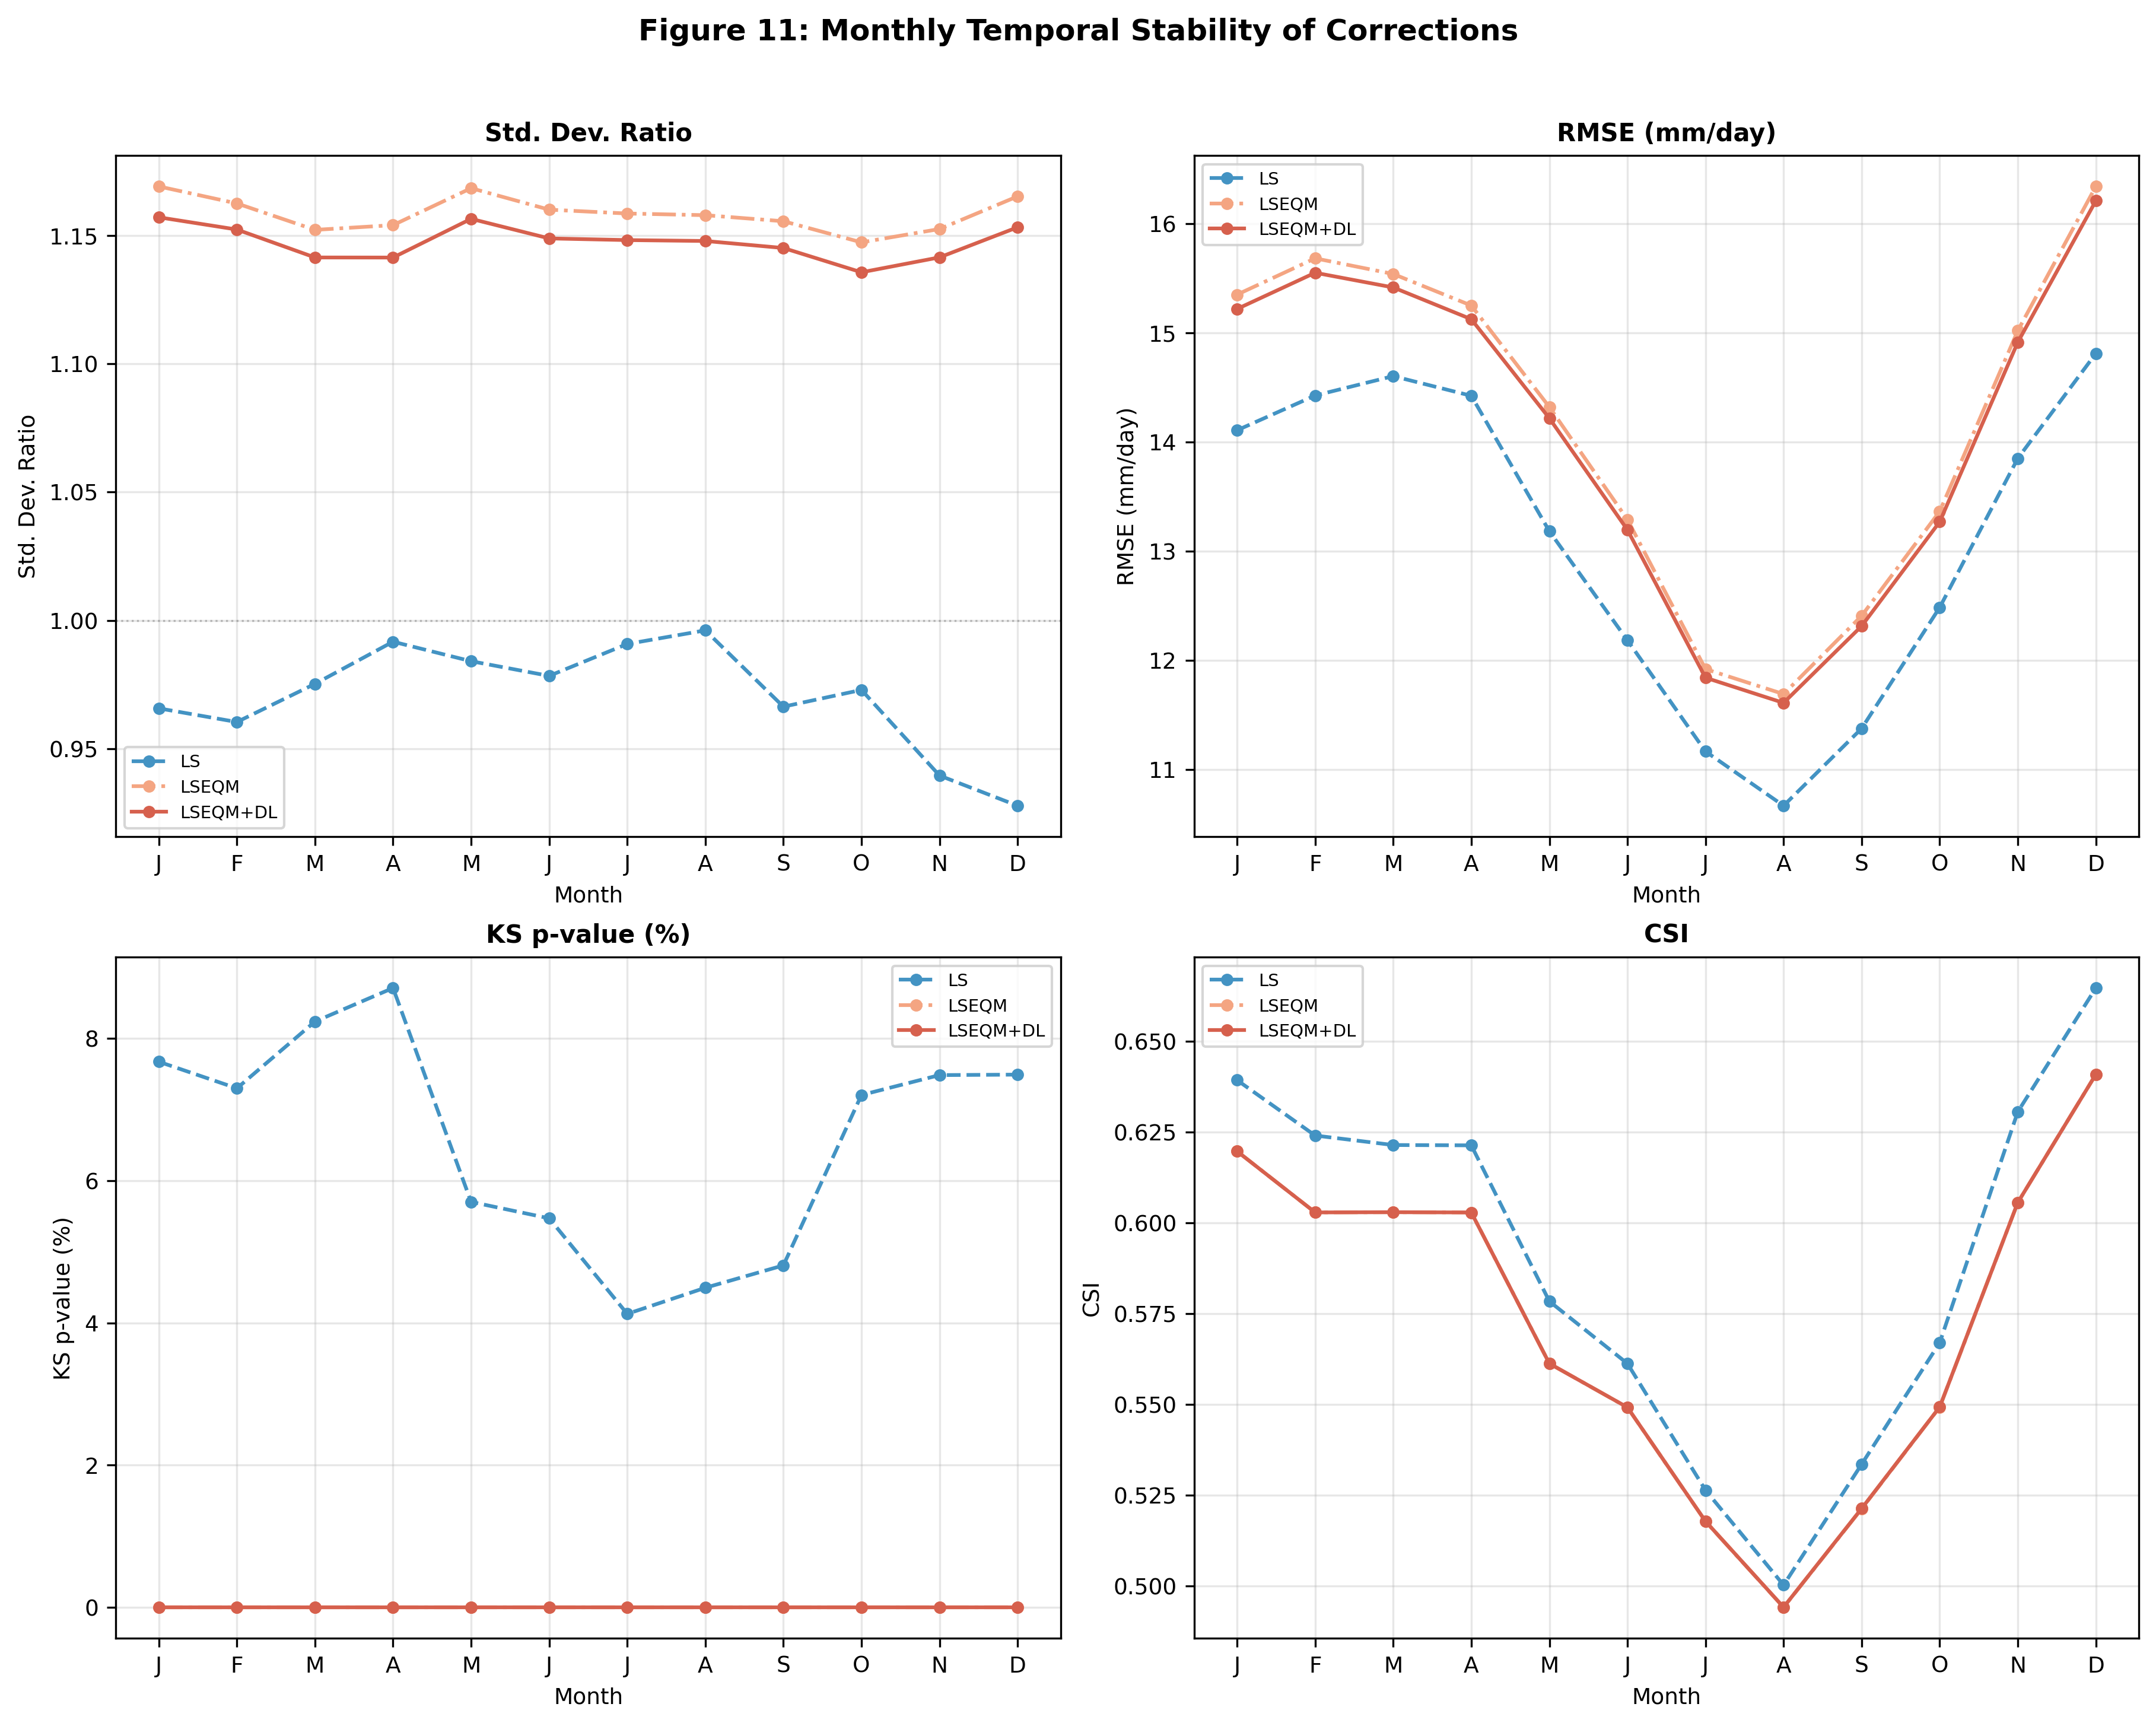

In [40]:
# -- Supplementary: Temporal stability ----------------------------------------

# Aggregate metrics by month (average across 3 dekads within each month)
monthly_metrics = {m: {k: {mo: [] for mo in range(1, 13)}
                       for k in ['stdev_ratio', 'rmse', 'ks_pvalue', 'csi']}
                   for m in METHODS}

for method in METHODS:
    for month, dekad in ALL_PERIODS:
        fpath = metrics_path(method, month, dekad)
        if not os.path.exists(fpath):
            continue
        ds = xr.open_dataset(fpath, decode_timedelta=False)
        medians = compute_spatial_medians(
            ds, ['stdev_ratio', 'rmse', 'ks_pvalue', 'csi'])
        for k in medians:
            if np.isfinite(medians[k]):
                monthly_metrics[method][k][month].append(medians[k])
        ds.close()

# Plot
plot_vars = [
    ('stdev_ratio', 'Std. Dev. Ratio', 1.0),
    ('rmse', 'RMSE (mm/day)', None),
    ('ks_pvalue', 'KS p-value (%)', None),
    ('csi', 'CSI', None),
]

method_colors = {'ls': '#4393c3', 'lseqm': '#f4a582', 'lseqmdl': '#d6604d'}
method_styles = {'ls': '--', 'lseqm': '-.', 'lseqmdl': '-'}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

for ax, (var, label, ideal) in zip(axes.ravel(), plot_vars):
    for method, mlabel in zip(METHODS, METHOD_LABELS):
        months_x = list(range(1, 13))
        vals_y = []
        for mo in months_x:
            v_list = monthly_metrics[method][var][mo]
            vals_y.append(np.mean(v_list) if v_list else np.nan)
        # Convert KS p-value from 0-1 scale to percentage
        if var == 'ks_pvalue':
            vals_y = [v * 100 if np.isfinite(v) else v for v in vals_y]
        ax.plot(months_x, vals_y,
                color=method_colors[method],
                linestyle=method_styles[method],
                marker='o', markersize=4,
                label=mlabel, linewidth=1.5)

    if ideal is not None:
        ax.axhline(ideal, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)

    ax.set_title(label, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_xlabel('Month')
    ax.set_ylabel(label)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Figure 11: Monthly Temporal Stability of Corrections',
             fontsize=12, fontweight='bold', y=1.06)

save_fig(fig, 'fig11_temporal_stability.png')
plt.show()

## Step 14 — Summary: Paper Fill-In Values

Consolidated summary of all numerical values needed for the paper text,
organized by section.

In [36]:
# -- Summary: Paper fill-in values --------------------------------------------

def fmt(val, decimals=4):
    """Format a value for display."""
    if np.isfinite(val):
        return f'{val:.{decimals}f}'
    return 'N/A'


print('=' * 80)
print('PAPER FILL-IN VALUES')
print('=' * 80)

# -- Abstract fill-in ---------------------------------------------------------
print('\n--- ABSTRACT ---')
t4 = table4_means
print(f'Domain-wide Relative Bias:  LS={fmt(t4["ls"]["relative_bias"])}, '
      f'LSEQM={fmt(t4["lseqm"]["relative_bias"])}, '
      f'LSEQM+DL={fmt(t4["lseqmdl"]["relative_bias"])}')
print(f'Domain-wide Stdev Ratio:    LS={fmt(t4["ls"]["stdev_ratio"])}, '
      f'LSEQM={fmt(t4["lseqm"]["stdev_ratio"])}, '
      f'LSEQM+DL={fmt(t4["lseqmdl"]["stdev_ratio"])}')
print(f'Domain-wide KS p-value (%): LS={fmt(t4["ls"]["ks_pvalue"], 2)}, '
      f'LSEQM={fmt(t4["lseqm"]["ks_pvalue"], 2)}, '
      f'LSEQM+DL={fmt(t4["lseqmdl"]["ks_pvalue"], 2)}')
print(f'Domain-wide Q99 Ratio:      LS={fmt(t4["ls"]["p99_ratio"])}, '
      f'LSEQM={fmt(t4["lseqm"]["p99_ratio"])}, '
      f'LSEQM+DL={fmt(t4["lseqmdl"]["p99_ratio"])}')
print(f'Station RB:                 LS={fmt(sta_medians["ls"]["relative_bias"])}, '
      f'LSEQM={fmt(sta_medians["lseqm"]["relative_bias"])}, '
      f'LSEQM+DL={fmt(sta_medians["lseqmdl"]["relative_bias"])}')
print(f'Station Stdev Ratio:        LS={fmt(sta_medians["ls"]["stdev_ratio"])}, '
      f'LSEQM={fmt(sta_medians["lseqm"]["stdev_ratio"])}, '
      f'LSEQM+DL={fmt(sta_medians["lseqmdl"]["stdev_ratio"])}')

# -- Table 4 fill-in ----------------------------------------------------------
print('\n--- TABLE 4 (Domain-Wide) ---')
all_t4_metrics_flat = {}
for pillar_name, pillar_metrics in PILLAR_METRICS.items():
    for key, (label, ideal) in pillar_metrics.items():
        all_t4_metrics_flat[key] = label
for key, (label, ideal) in TEMPORAL_METRICS.items():
    all_t4_metrics_flat[key] = label

for key, label in all_t4_metrics_flat.items():
    vals = [t4[m].get(key, np.nan) for m in METHODS]
    print(f'{label:<28} LS={fmt(vals[0])}  LSEQM={fmt(vals[1])}  LSEQM+DL={fmt(vals[2])}')

# -- Table 5 fill-in ----------------------------------------------------------
print('\n--- TABLE 5 (Percentile Fidelity) ---')
for p, plabel in zip(PCTL_VARS, PCTL_LABELS):
    ref_val = (np.mean(table5_data['ls'][p]['ref'])
               if table5_data['ls'][p]['ref'] else np.nan)
    test_vals = []
    for method in METHODS:
        tv = (np.mean(table5_data[method][p]['test'])
              if table5_data[method][p]['test'] else np.nan)
        test_vals.append(tv)
    print(f'{plabel}: Ref={fmt(ref_val, 2)}  '
          f'LS={fmt(test_vals[0], 2)}  '
          f'LSEQM={fmt(test_vals[1], 2)}  '
          f'LSEQM+DL={fmt(test_vals[2], 2)}')

# -- Table 7 fill-in ----------------------------------------------------------
print('\n--- TABLE 7 (Station Validation) ---')
for key, label in all_t4_metrics_flat.items():
    vals = [sta_medians[m].get(key, np.nan) for m in METHODS]
    print(f'{label:<28} LS={fmt(vals[0])}  LSEQM={fmt(vals[1])}  LSEQM+DL={fmt(vals[2])}')

# -- CQI fill-in --------------------------------------------------------------
print('\n--- CQI VALUES ---')
for method, mlabel in zip(METHODS, METHOD_LABELS):
    if method in cqi_maps:
        med = np.nanmedian(cqi_maps[method])
        mean_val = np.nanmean(cqi_maps[method])
        print(f'{mlabel}: median CQI={fmt(med)}, mean CQI={fmt(mean_val)}')

# -- Section narrative fill-in -------------------------------------------------
print('\n--- SECTION NARRATIVE VALUES ---')

# KS improvement
ks_ls = t4['ls']['ks_pvalue']
ks_lseqm = t4['lseqm']['ks_pvalue']
if np.isfinite(ks_ls) and np.isfinite(ks_lseqm) and ks_ls > 0:
    ks_pct_change = 100.0 * (ks_lseqm - ks_ls) / ks_ls
    print(f'KS p-value improvement (LS->LSEQM): {ks_pct_change:+.1f}%')

# Q99 improvement
q99_ls = t4['ls']['p99_ratio']
q99_lseqm = t4['lseqm']['p99_ratio']
print(f'Q99 Ratio: LS={fmt(q99_ls)} -> LSEQM={fmt(q99_lseqm)} '
      f'(closer to 1.0 by {abs(1.0 - q99_lseqm) - abs(1.0 - q99_ls):.4f})')

# RMSE comparison
rmse_ls = t4['ls']['rmse']
rmse_dl = t4['lseqmdl']['rmse']
if np.isfinite(rmse_ls) and np.isfinite(rmse_dl) and rmse_ls > 0:
    rmse_pct = 100.0 * (rmse_dl - rmse_ls) / rmse_ls
    print(f'RMSE change (LS->LSEQM+DL): {rmse_pct:+.2f}%')

# Station stdev improvement
sta_sd_ls = sta_medians['ls']['stdev_ratio']
sta_sd_lseqm = sta_medians['lseqm']['stdev_ratio']
sta_sd_dl = sta_medians['lseqmdl']['stdev_ratio']
print(f'Station Stdev Ratio: LS={fmt(sta_sd_ls)} -> LSEQM={fmt(sta_sd_lseqm)} '
      f'-> LSEQM+DL={fmt(sta_sd_dl)}')

# Station KS improvement
sta_ks_ls = sta_medians['ls']['ks_pvalue']
sta_ks_lseqm = sta_medians['lseqm']['ks_pvalue']
if np.isfinite(sta_ks_ls) and np.isfinite(sta_ks_lseqm):
    print(f'Station KS p-value: LS={fmt(sta_ks_ls, 2)}% -> '
          f'LSEQM={fmt(sta_ks_lseqm, 2)}% '
          f'(+{sta_ks_lseqm - sta_ks_ls:.2f} pp)')

print('\n' + '=' * 80)
print('All paper fill-in values generated successfully.')

PAPER FILL-IN VALUES

--- ABSTRACT ---
Domain-wide Relative Bias:  LS=0.0000, LSEQM=0.0697, LSEQM+DL=0.0652
Domain-wide Stdev Ratio:    LS=0.9707, LSEQM=1.1587, LSEQM+DL=1.1475
Domain-wide KS p-value (%): LS=0.07, LSEQM=0.00, LSEQM+DL=0.00
Domain-wide Q99 Ratio:      LS=0.9669, LSEQM=1.2117, LSEQM+DL=1.1964
Station RB:                 LS=-0.1139, LSEQM=0.0087, LSEQM+DL=-0.0057
Station Stdev Ratio:        LS=0.7148, LSEQM=1.0272, LSEQM+DL=0.9994

--- TABLE 4 (Domain-Wide) ---
Relative Bias                LS=0.0000  LSEQM=0.0697  LSEQM+DL=0.0652
Std. Dev. Ratio              LS=0.9707  LSEQM=1.1587  LSEQM+DL=1.1475
KS p-value (%)               LS=0.0656  LSEQM=0.0000  LSEQM+DL=0.0000
Wet-Day Freq. Ratio          LS=1.0397  LSEQM=0.9466  LSEQM+DL=0.9462
Mean Wet-Day Precip Ratio    LS=0.9611  LSEQM=1.1569  LSEQM+DL=1.1519
Q95 Ratio                    LS=0.9459  LSEQM=1.1711  LSEQM+DL=1.1626
Q99 Ratio                    LS=0.9669  LSEQM=1.2117  LSEQM+DL=1.1964
POD                          L